# GenkiClean Inventory EDA | Vending Machine Operations Analysis

## Project Overview

This notebook presents an Exploratory Data Analysis of GenkiClean's daily vending machine inventory dataset.

The dataset tracks daily inventory behavior across vending machines, products, locations, refills, liters dispensed, reorder points, and stockout events.

The objective of this analysis is to identify operational patterns, inventory risks, refill efficiency, product rotation, and potential stockout issues that can support better decision-making for vending machine operations.

## Business Context

GenkiClean operates vending machines for cleaning products. Since each machine has limited tank capacity and product availability directly affects sales potential, inventory monitoring is critical.

This analysis focuses on answering questions such as:

1. Which products have the highest daily consumption?
2. Which machines or locations require more frequent refills?
3. How often does inventory fall below the reorder point?
4. Are there stockout events that may represent lost sales?
5. What products or locations show stronger rotation?
6. How can inventory planning be improved?

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

# Visualization style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Data Loading

The dataset is stored in Google Sheets.  
To analyze it in Python, the spreadsheet is loaded directly as a CSV file using the Google Sheets export URL.

The spreadsheet ID and worksheet `gid` are extracted from the shared Google Sheets link.

In [2]:
# Google Sheets URL shared for the analysis
sheet_url = "https://docs.google.com/spreadsheets/d/1rXgjVeIPvd6AinfCMBwWZI0NLv9-BP0nGGSm0MUCYN4/edit?usp=sharing"

# Spreadsheet ID and worksheet GID
sheet_id = "1rXgjVeIPvd6AinfCMBwWZI0NLv9-BP0nGGSm0MUCYN4"
gid = "1590109598"

# Convert Google Sheets URL into CSV export URL
csv_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

# Load dataset
df = pd.read_csv(csv_url)

# Preview first rows
df.head()

,date,year_month,machine_id,city,region,location_type,product_id,product_name,opening_inventory_l,liters_refilled_l,available_after_refill_l,liters_dispensed_l,closing_inventory_l,tank_capacity_l,inventory_fill_pct,days_since_last_refill,reorder_point_l,refill_needed_flag,stockout_flag,stockout_minutes
0,2025-01-01,2025-01,VM-001,Monterrey,Norte,Hotel,P01,Detergente multiusos,55.26,0.00,55.26,2.43,52.83,70,0.75,3,18,0,0,0
1,2025-01-02,2025-01,VM-001,Monterrey,Norte,Hotel,P01,Detergente multiusos,52.83,0.00,52.83,3.44,49.39,70,0.71,4,18,0,0,0
2,2025-01-03,2025-01,VM-001,Monterrey,Norte,Hotel,P01,Detergente multiusos,49.39,0.00,49.39,3.33,46.06,70,0.66,5,18,0,0,0
3,2025-01-04,2025-01,VM-001,Monterrey,Norte,Hotel,P01,Detergente multiusos,46.06,0.00,46.06,3.12,42.94,70,0.61,6,18,0,0,0
4,2025-01-05,2025-01,VM-001,Monterrey,Norte,Hotel,P01,Detergente multiusos,42.94,0.00,42.94,2.86,40.08,70,0.57,7,18,0,0,0


### Loading Validation

After loading the dataset, the first step is to validate that the file was imported correctly.

This includes checking:

- Number of rows and columns
- First rows of the dataset
- Column names
- General structure

In [3]:
# Dataset shape
rows, columns = df.shape

print(f"The dataset contains {rows:,} rows and {columns:,} columns.")

The dataset contains 183,960 rows and 20 columns.


In [4]:
# Display first 5 rows
df.head()

,date,year_month,machine_id,city,region,location_type,product_id,product_name,opening_inventory_l,liters_refilled_l,available_after_refill_l,liters_dispensed_l,closing_inventory_l,tank_capacity_l,inventory_fill_pct,days_since_last_refill,reorder_point_l,refill_needed_flag,stockout_flag,stockout_minutes
0,2025-01-01,2025-01,VM-001,Monterrey,Norte,Hotel,P01,Detergente multiusos,55.26,0.00,55.26,2.43,52.83,70,0.75,3,18,0,0,0
1,2025-01-02,2025-01,VM-001,Monterrey,Norte,Hotel,P01,Detergente multiusos,52.83,0.00,52.83,3.44,49.39,70,0.71,4,18,0,0,0
2,2025-01-03,2025-01,VM-001,Monterrey,Norte,Hotel,P01,Detergente multiusos,49.39,0.00,49.39,3.33,46.06,70,0.66,5,18,0,0,0
3,2025-01-04,2025-01,VM-001,Monterrey,Norte,Hotel,P01,Detergente multiusos,46.06,0.00,46.06,3.12,42.94,70,0.61,6,18,0,0,0
4,2025-01-05,2025-01,VM-001,Monterrey,Norte,Hotel,P01,Detergente multiusos,42.94,0.00,42.94,2.86,40.08,70,0.57,7,18,0,0,0


In [5]:
# Display last 5 rows
df.tail()

,date,year_month,machine_id,city,region,location_type,product_id,product_name,opening_inventory_l,liters_refilled_l,available_after_refill_l,liters_dispensed_l,closing_inventory_l,tank_capacity_l,inventory_fill_pct,days_since_last_refill,reorder_point_l,refill_needed_flag,stockout_flag,stockout_minutes
183955,2025-12-27,2025-12,VM-072,Ciudad de México,Centro,Centro comercial,P07,Sanitizante,12.28,0.00,12.28,3.24,9.04,70,0.13,10,14,1,0,0
183956,2025-12-28,2025-12,VM-072,Ciudad de México,Centro,Centro comercial,P07,Sanitizante,9.04,0.00,9.04,8.60,0.44,70,0.01,11,14,1,0,0
183957,2025-12-29,2025-12,VM-072,Ciudad de México,Centro,Centro comercial,P07,Sanitizante,0.44,67.89,68.33,4.90,63.43,70,0.91,0,14,0,0,0
183958,2025-12-30,2025-12,VM-072,Ciudad de México,Centro,Centro comercial,P07,Sanitizante,63.43,0.00,63.43,6.02,57.41,70,0.82,1,14,0,0,0
183959,2025-12-31,2025-12,VM-072,Ciudad de México,Centro,Centro comercial,P07,Sanitizante,57.41,0.00,57.41,14.15,43.26,70,0.62,2,14,0,0,0


## 2. Initial Data Inspection

Before cleaning or analyzing the data, it is necessary to understand the dataset structure.

This section reviews:

- Column names
- Data types
- Non-null values
- Missing values
- General dataset composition

In [6]:
# List all column names
df.columns.tolist()

['date',
 'year_month',
 'machine_id',
 'city',
 'region',
 'location_type',
 'product_id',
 'product_name',
 'opening_inventory_l',
 'liters_refilled_l',
 'available_after_refill_l',
 'liters_dispensed_l',
 'closing_inventory_l',
 'tank_capacity_l',
 'inventory_fill_pct',
 'days_since_last_refill',
 'reorder_point_l',
 'refill_needed_flag',
 'stockout_flag',
 'stockout_minutes']

In [7]:
# General dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183960 entries, 0 to 183959
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   date                      183960 non-null  object 
 1   year_month                183960 non-null  object 
 2   machine_id                183960 non-null  object 
 3   city                      183960 non-null  object 
 4   region                    183960 non-null  object 
 5   location_type             183960 non-null  object 
 6   product_id                183960 non-null  object 
 7   product_name              183960 non-null  object 
 8   opening_inventory_l       183960 non-null  float64
 9   liters_refilled_l         183960 non-null  float64
 10  available_after_refill_l  183960 non-null  float64
 11  liters_dispensed_l        183960 non-null  float64
 12  closing_inventory_l       183960 non-null  float64
 13  tank_capacity_l           183960 non-null  i

In [8]:
# Data type summary
data_types_summary = pd.DataFrame({
    "column": df.columns,
    "data_type": df.dtypes.astype(str),
    "non_null_values": df.notnull().sum().values,
    "null_values": df.isnull().sum().values,
    "null_percentage": (df.isnull().mean().values * 100).round(2)
})

data_types_summary

,column,data_type,non_null_values,null_values,null_percentage
date,date,object,183960,0,0.00
year_month,year_month,object,183960,0,0.00
machine_id,machine_id,object,183960,0,0.00
city,city,object,183960,0,0.00
region,region,object,183960,0,0.00
location_type,location_type,object,183960,0,0.00
product_id,product_id,object,183960,0,0.00
product_name,product_name,object,183960,0,0.00
opening_inventory_l,opening_inventory_l,float64,183960,0,0.00
liters_refilled_l,liters_refilled_l,float64,183960,0,0.00


### Initial Structure Notes

At this stage, the goal is to verify whether the dataset is ready for analysis.

The expected structure includes:

- Date-related fields such as `date` and `year_month`
- Machine and location fields such as `machine_id`, `city`, `region`, and `location_type`
- Product fields such as `product_id` and `product_name`
- Inventory metrics such as opening inventory, refills, available inventory, dispensed liters, and closing inventory
- Operational flags such as refill needed and stockout events

The next step is to standardize column names and validate data quality.

## 3. Column Name Standardization

Column names are standardized to make them easier to use in Python.

The standard format applied is:

- Lowercase text
- No leading or trailing spaces
- Underscores instead of spaces
- No special characters where possible

In [9]:
# Preserve original dataset before cleaning
df_raw = df.copy()

# Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("/", "_")
    .str.replace(".", "", regex=False)
)

# Display standardized column names
df.columns.tolist()

['date',
 'year_month',
 'machine_id',
 'city',
 'region',
 'location_type',
 'product_id',
 'product_name',
 'opening_inventory_l',
 'liters_refilled_l',
 'available_after_refill_l',
 'liters_dispensed_l',
 'closing_inventory_l',
 'tank_capacity_l',
 'inventory_fill_pct',
 'days_since_last_refill',
 'reorder_point_l',
 'refill_needed_flag',
 'stockout_flag',
 'stockout_minutes']

In [10]:
# Confirm dataset structure after column standardization
df.head()

,date,year_month,machine_id,city,region,location_type,product_id,product_name,opening_inventory_l,liters_refilled_l,available_after_refill_l,liters_dispensed_l,closing_inventory_l,tank_capacity_l,inventory_fill_pct,days_since_last_refill,reorder_point_l,refill_needed_flag,stockout_flag,stockout_minutes
0,2025-01-01,2025-01,VM-001,Monterrey,Norte,Hotel,P01,Detergente multiusos,55.26,0.00,55.26,2.43,52.83,70,0.75,3,18,0,0,0
1,2025-01-02,2025-01,VM-001,Monterrey,Norte,Hotel,P01,Detergente multiusos,52.83,0.00,52.83,3.44,49.39,70,0.71,4,18,0,0,0
2,2025-01-03,2025-01,VM-001,Monterrey,Norte,Hotel,P01,Detergente multiusos,49.39,0.00,49.39,3.33,46.06,70,0.66,5,18,0,0,0
3,2025-01-04,2025-01,VM-001,Monterrey,Norte,Hotel,P01,Detergente multiusos,46.06,0.00,46.06,3.12,42.94,70,0.61,6,18,0,0,0
4,2025-01-05,2025-01,VM-001,Monterrey,Norte,Hotel,P01,Detergente multiusos,42.94,0.00,42.94,2.86,40.08,70,0.57,7,18,0,0,0


## 4. Initial Data Quality Assessment

This section checks for basic data quality issues that could affect the analysis.

The assessment includes:

- Missing values
- Duplicate records
- Empty columns
- Basic descriptive statistics
- Potential data type inconsistencies

In [11]:
# Missing values summary
missing_values = pd.DataFrame({
    "missing_values": df.isnull().sum(),
    "missing_percentage": (df.isnull().mean() * 100).round(2)
})

missing_values = missing_values.sort_values(
    by="missing_percentage", 
    ascending=False
)

missing_values

,missing_values,missing_percentage
date,0,0.00
year_month,0,0.00
stockout_flag,0,0.00
refill_needed_flag,0,0.00
reorder_point_l,0,0.00
days_since_last_refill,0,0.00
inventory_fill_pct,0,0.00
tank_capacity_l,0,0.00
closing_inventory_l,0,0.00
liters_dispensed_l,0,0.00


In [12]:
# Columns with missing values only
missing_values[missing_values["missing_values"] > 0]

,missing_values,missing_percentage


In [13]:
# Check duplicate rows
duplicate_rows = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_rows:,}")

Number of duplicate rows: 0


In [14]:
# Identify completely empty columns
empty_columns = df.columns[df.isnull().all()].tolist()

print("Completely empty columns:")
empty_columns

Completely empty columns:


[]

In [15]:
# Descriptive statistics for categorical columns
df.describe(include="object").T

,count,unique,top,freq
date,183960,365,2025-01-01,504
year_month,183960,12,2025-01,15624
machine_id,183960,72,VM-001,2555
city,183960,8,Ciudad de México,45990
region,183960,6,Centro,74095
location_type,183960,6,Centro comercial,45990
product_id,183960,7,P01,26280
product_name,183960,7,Detergente multiusos,26280


## 5. Inventory Dataset Validation

Since this dataset tracks daily inventory behavior, it is important to validate key operational variables.

The following checks help confirm whether the data behaves as expected:

- Date range available in the dataset
- Number of machines
- Number of products
- Number of cities and regions
- Number of product-location-machine combinations

In [16]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Validate conversion
df["date"].head()

0   2025-01-01
1   2025-01-02
2   2025-01-03
3   2025-01-04
4   2025-01-05
Name: date, dtype: datetime64[ns]

In [17]:
# Date range
min_date = df["date"].min()
max_date = df["date"].max()

print(f"Date range: {min_date.date()} to {max_date.date()}")

Date range: 2025-01-01 to 2025-12-31


In [18]:
# Key dataset counts
summary_counts = {
    "total_rows": len(df),
    "total_columns": df.shape[1],
    "unique_machines": df["machine_id"].nunique(),
    "unique_products": df["product_id"].nunique(),
    "unique_product_names": df["product_name"].nunique(),
    "unique_cities": df["city"].nunique(),
    "unique_regions": df["region"].nunique(),
    "unique_location_types": df["location_type"].nunique()
}

summary_counts

{'total_rows': 183960,
 'total_columns': 20,
 'unique_machines': 72,
 'unique_products': 7,
 'unique_product_names': 7,
 'unique_cities': 8,
 'unique_regions': 6,
 'unique_location_types': 6}

In [19]:
# Product catalog found in the dataset
product_catalog = (
    df[["product_id", "product_name"]]
    .drop_duplicates()
    .sort_values(by="product_id")
    .reset_index(drop=True)
)

product_catalog

,product_id,product_name
0,P01,Detergente multiusos
1,P02,Desinfectante
2,P03,Jabón para trastes
3,P04,Limpiador de pisos
4,P05,Suavizante
5,P06,Cloro
6,P07,Sanitizante


In [20]:
# Machine and location summary
machine_location_summary = (
    df[["machine_id", "city", "region", "location_type"]]
    .drop_duplicates()
    .sort_values(by=["machine_id", "city"])
    .reset_index(drop=True)
)

machine_location_summary

,machine_id,city,region,location_type
0,VM-001,Monterrey,Norte,Hotel
1,VM-002,Ciudad de México,Centro,Hotel
2,VM-003,Guadalajara,Occidente,Universidad
3,VM-004,Monterrey,Norte,Hotel
4,VM-005,Tijuana,Noroeste,Hotel
5,VM-006,Monterrey,Norte,Parque industrial
6,VM-007,Ciudad de México,Centro,Centro comercial
7,VM-008,Puebla,Centro,Hotel
8,VM-009,Tijuana,Noroeste,Hospital
9,VM-010,Guadalajara,Occidente,Parque industrial


## 6. Initial Findings

The dataset was successfully loaded from Google Sheets and contains daily inventory records for GenkiClean vending machine operations.

The initial inspection focused on understanding the dataset structure, validating data quality, and identifying the main business entities available for analysis.

At this stage, the dataset appears to support an operational inventory analysis based on:

- Daily inventory movement
- Product-level consumption
- Machine-level inventory performance
- Refill behavior
- Reorder point monitoring
- Stockout detection

The next step is to clean and validate numeric fields before performing deeper exploratory analysis on product rotation, refill frequency, inventory risk, and stockout behavior.

In [21]:
df.head()
df.info()
data_types_summary
missing_values
df.describe().T
summary_counts
product_catalog
machine_location_summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183960 entries, 0 to 183959
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   date                      183960 non-null  datetime64[ns]
 1   year_month                183960 non-null  object        
 2   machine_id                183960 non-null  object        
 3   city                      183960 non-null  object        
 4   region                    183960 non-null  object        
 5   location_type             183960 non-null  object        
 6   product_id                183960 non-null  object        
 7   product_name              183960 non-null  object        
 8   opening_inventory_l       183960 non-null  float64       
 9   liters_refilled_l         183960 non-null  float64       
 10  available_after_refill_l  183960 non-null  float64       
 11  liters_dispensed_l        183960 non-null  float64       
 12  cl

,machine_id,city,region,location_type
0,VM-001,Monterrey,Norte,Hotel
1,VM-002,Ciudad de México,Centro,Hotel
2,VM-003,Guadalajara,Occidente,Universidad
3,VM-004,Monterrey,Norte,Hotel
4,VM-005,Tijuana,Noroeste,Hotel
5,VM-006,Monterrey,Norte,Parque industrial
6,VM-007,Ciudad de México,Centro,Centro comercial
7,VM-008,Puebla,Centro,Hotel
8,VM-009,Tijuana,Noroeste,Hospital
9,VM-010,Guadalajara,Occidente,Parque industrial


## 7. Visual Exploratory Data Analysis

This section uses data visualization to identify inventory behavior patterns across products, machines, locations, refills, and stockout events.

The objective is to move from basic data inspection to business-oriented insights that can support operational decisions such as:

- Product rotation planning
- Refill prioritization
- Stockout prevention
- Machine-level inventory monitoring
- Reorder point optimization

Seaborn is used to create clear and professional visualizations suitable for a data analytics portfolio.

In [22]:
# Visualization configuration
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

print("Visualization settings configured.")

Visualization settings configured.


## 8. Feature Preparation for Visualization

Before creating charts, some variables are prepared to make the analysis easier.

This includes:

- Ensuring numeric inventory fields are correctly formatted
- Creating inventory fill percentage
- Creating refill and stockout event indicators
- Creating reorder risk indicators

In [23]:
# Expected columns for the inventory analysis
expected_columns = [
    "date",
    "year_month",
    "machine_id",
    "city",
    "region",
    "location_type",
    "product_id",
    "product_name",
    "opening_inventory_l",
    "liters_refilled_l",
    "available_after_refill_l",
    "liters_dispensed_l",
    "closing_inventory_l",
    "tank_capacity_l",
    "reorder_point_l",
    "refill_flag",
    "stockout_flag",
    "stockout_minutes"
]

missing_columns = [col for col in expected_columns if col not in df.columns]

if len(missing_columns) == 0:
    print("All expected columns are available.")
else:
    print("Missing columns:")
    print(missing_columns)

Missing columns:
['refill_flag']


In [24]:
# Numeric columns expected in the dataset
numeric_columns = [
    "opening_inventory_l",
    "liters_refilled_l",
    "available_after_refill_l",
    "liters_dispensed_l",
    "closing_inventory_l",
    "tank_capacity_l",
    "reorder_point_l",
    "stockout_minutes"
]

# Convert numeric columns safely
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Confirm data types
df[numeric_columns].dtypes

opening_inventory_l         float64
liters_refilled_l           float64
available_after_refill_l    float64
liters_dispensed_l          float64
closing_inventory_l         float64
tank_capacity_l               int64
reorder_point_l               int64
stockout_minutes              int64
dtype: object

In [25]:
# Create calculated inventory variables

# Inventory fill percentage
df["inventory_fill_pct"] = df["closing_inventory_l"] / df["tank_capacity_l"]

# Avoid infinite values if tank capacity is zero
df["inventory_fill_pct"] = df["inventory_fill_pct"].replace([np.inf, -np.inf], np.nan)

# Reorder risk event
# A product is at reorder risk when closing inventory is equal to or below the reorder point
df["reorder_risk_event"] = df["closing_inventory_l"] <= df["reorder_point_l"]

# Refill event
# If a refill flag column exists, use it.
# If not, infer refill events from liters_refilled_l > 0.
if "refill_flag" in df.columns:
    df["refill_event"] = df["refill_flag"].astype(str).str.lower().isin(
        ["1", "true", "yes", "y", "si", "sí"]
    )
else:
    df["refill_event"] = df["liters_refilled_l"] > 0

# Stockout event
# If a stockout flag column exists, use it.
# If not, infer stockouts from stockout_minutes > 0.
if "stockout_flag" in df.columns:
    df["stockout_event"] = df["stockout_flag"].astype(str).str.lower().isin(
        ["1", "true", "yes", "y", "si", "sí"]
    )
else:
    df["stockout_event"] = df["stockout_minutes"] > 0

# Preview calculated variables
df[
    [
        "date",
        "machine_id",
        "product_name",
        "liters_dispensed_l",
        "liters_refilled_l",
        "closing_inventory_l",
        "tank_capacity_l",
        "inventory_fill_pct",
        "reorder_point_l",
        "reorder_risk_event",
        "refill_event",
        "stockout_event",
        "stockout_minutes"
    ]
].head()

,date,machine_id,product_name,liters_dispensed_l,liters_refilled_l,closing_inventory_l,tank_capacity_l,inventory_fill_pct,reorder_point_l,reorder_risk_event,refill_event,stockout_event,stockout_minutes
0,2025-01-01,VM-001,Detergente multiusos,2.43,0.00,52.83,70,0.75,18,False,False,False,0
1,2025-01-02,VM-001,Detergente multiusos,3.44,0.00,49.39,70,0.71,18,False,False,False,0
2,2025-01-03,VM-001,Detergente multiusos,3.33,0.00,46.06,70,0.66,18,False,False,False,0
3,2025-01-04,VM-001,Detergente multiusos,3.12,0.00,42.94,70,0.61,18,False,False,False,0
4,2025-01-05,VM-001,Detergente multiusos,2.86,0.00,40.08,70,0.57,18,False,False,False,0


## 9. Calculated Variables Validation

After creating the operational variables, the next step is to validate that they were generated correctly.

The calculated variables are:

- `inventory_fill_pct`: closing inventory divided by tank capacity.
- `reorder_risk_event`: identifies when closing inventory is at or below the reorder point.
- `refill_event`: identifies whether a refill occurred.
- `stockout_event`: identifies whether a stockout occurred.

These variables will be used throughout the visual exploratory analysis.

In [26]:
# Validate calculated variables
calculated_columns = [
    "inventory_fill_pct",
    "reorder_risk_event",
    "refill_event",
    "stockout_event"
]

df[calculated_columns].head()

,inventory_fill_pct,reorder_risk_event,refill_event,stockout_event
0,0.75,False,False,False
1,0.71,False,False,False
2,0.66,False,False,False
3,0.61,False,False,False
4,0.57,False,False,False


In [27]:
# Count operational events
event_summary = pd.DataFrame({
    "metric": [
        "Reorder risk events",
        "Refill events",
        "Stockout events"
    ],
    "event_count": [
        df["reorder_risk_event"].sum(),
        df["refill_event"].sum(),
        df["stockout_event"].sum()
    ]
})

event_summary

,metric,event_count
0,Reorder risk events,18721
1,Refill events,14967
2,Stockout events,201


### Validation Insight

The calculated operational variables allow the analysis to move beyond raw inventory data.

Instead of only reviewing liters dispensed or liters refilled, the notebook can now identify business-relevant events such as refill activity, reorder risk, and stockout exposure.

These indicators are important because they help translate inventory data into operational decisions.

## 10. Executive KPI Summary

This section summarizes the most important inventory performance indicators.

The goal is to provide a high-level view of the vending machine operation before moving into detailed visual analysis.

The KPIs include:

- Total liters dispensed
- Total liters refilled
- Average daily liters dispensed
- Refill events
- Stockout events
- Stockout minutes
- Average inventory fill percentage
- Reorder risk events

In [28]:
# Executive inventory KPIs
inventory_kpis = pd.DataFrame({
    "metric": [
        "Total liters dispensed",
        "Total liters refilled",
        "Average daily liters dispensed",
        "Total refill events",
        "Total stockout events",
        "Total stockout minutes",
        "Average inventory fill percentage",
        "Reorder risk events"
    ],
    "value": [
        df["liters_dispensed_l"].sum(),
        df["liters_refilled_l"].sum(),
        df.groupby("date")["liters_dispensed_l"].sum().mean(),
        df["refill_event"].sum(),
        df["stockout_event"].sum(),
        df["stockout_minutes"].sum(),
        df["inventory_fill_pct"].mean(),
        df["reorder_risk_event"].sum()
    ]
})

inventory_kpis

,metric,value
0,Total liters dispensed,"773,274.75"
1,Total liters refilled,"770,533.69"
2,Average daily liters dispensed,"2,118.56"
3,Total refill events,"14,967.00"
4,Total stockout events,201.00
5,Total stockout minutes,"77,028.00"
6,Average inventory fill percentage,0.53
7,Reorder risk events,"18,721.00"


In [29]:
# Format KPI values for easier reading
inventory_kpis_formatted = inventory_kpis.copy()

inventory_kpis_formatted["value"] = inventory_kpis_formatted["value"].apply(
    lambda x: f"{x:,.2f}" if isinstance(x, (int, float, np.number)) else x
)

inventory_kpis_formatted

,metric,value
0,Total liters dispensed,"773,274.75"
1,Total liters refilled,"770,533.69"
2,Average daily liters dispensed,"2,118.56"
3,Total refill events,"14,967.00"
4,Total stockout events,201.00
5,Total stockout minutes,"77,028.00"
6,Average inventory fill percentage,0.53
7,Reorder risk events,"18,721.00"


### Executive Insight

The executive KPI summary provides a first view of inventory movement and operational risk.

From a business perspective, the most relevant indicators are total liters dispensed, refill events, reorder risk events, and stockout minutes.

These metrics help determine whether the vending machine operation is maintaining enough product availability or whether it needs stronger refill planning.

## 11. Daily Consumption Trend

This chart shows total liters dispensed per day.

The objective is to identify demand behavior over time and evaluate whether consumption is stable, increasing, decreasing, or concentrated on specific high-demand days.

A 7-day rolling average is added to smooth daily variation and make the trend easier to interpret.

In [30]:
# Daily liters dispensed
daily_consumption = (
    df.groupby("date", as_index=False)
    .agg(total_liters_dispensed=("liters_dispensed_l", "sum"))
    .sort_values("date")
)

# 7-day rolling average
daily_consumption["rolling_7d_avg"] = (
    daily_consumption["total_liters_dispensed"]
    .rolling(window=7, min_periods=1)
    .mean()
)

daily_consumption.head()

,date,total_liters_dispensed,rolling_7d_avg
0,2025-01-01,"1,744.36","1,744.36"
1,2025-01-02,"2,221.86","1,983.11"
2,2025-01-03,"2,385.71","2,117.31"
3,2025-01-04,"1,714.81","2,016.68"
4,2025-01-05,"1,478.77","1,909.10"


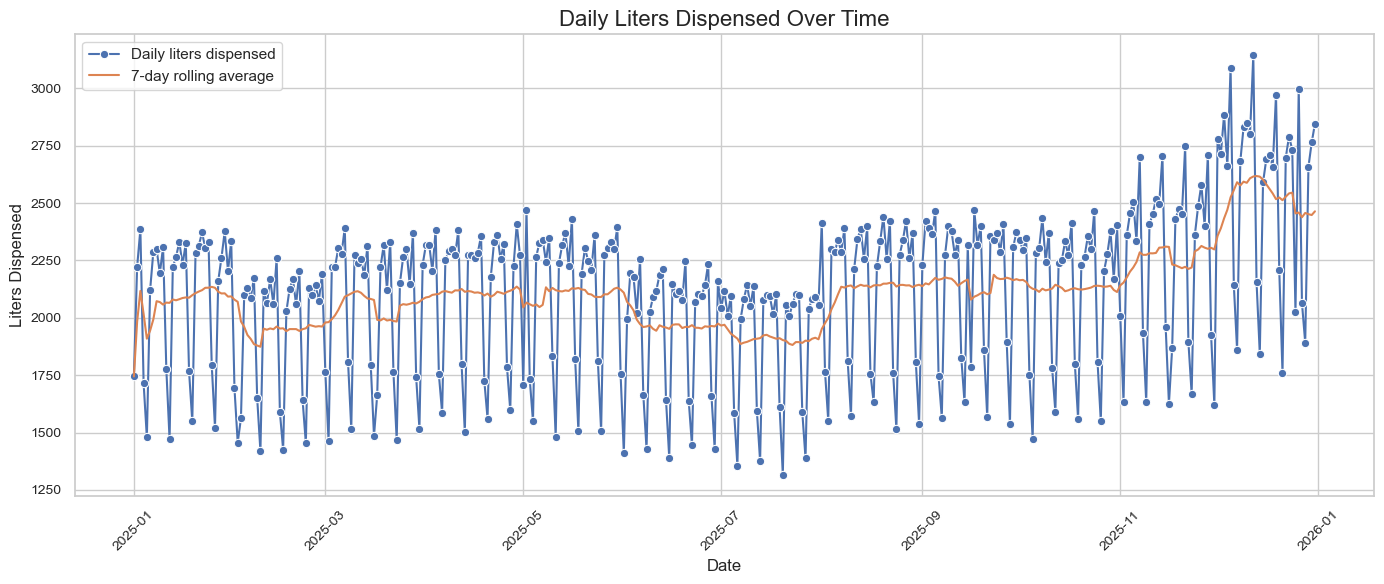

In [31]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=daily_consumption,
    x="date",
    y="total_liters_dispensed",
    marker="o",
    label="Daily liters dispensed"
)

sns.lineplot(
    data=daily_consumption,
    x="date",
    y="rolling_7d_avg",
    label="7-day rolling average"
)

plt.title("Daily Liters Dispensed Over Time")
plt.xlabel("Date")
plt.ylabel("Liters Dispensed")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
# Automatic insight
top_day = daily_consumption.loc[daily_consumption["total_liters_dispensed"].idxmax()]
avg_daily_liters = daily_consumption["total_liters_dispensed"].mean()

print(f"Highest consumption day: {top_day['date'].date()}")
print(f"Liters dispensed on highest day: {top_day['total_liters_dispensed']:.2f} L")
print(f"Average daily liters dispensed: {avg_daily_liters:.2f} L")

Highest consumption day: 2025-12-12
Liters dispensed on highest day: 3143.73 L
Average daily liters dispensed: 2118.56 L


### Business Insight

The daily consumption trend helps identify whether demand is consistent or concentrated in specific days.

If the rolling average increases over time, it may suggest stronger product adoption or higher vending machine usage. If the trend is volatile, refill planning should consider peak-demand days rather than relying only on average consumption.

This analysis supports better refill scheduling and helps reduce the risk of stockouts.

## 12. Product Rotation Analysis

Product rotation is one of the most important indicators in a vending machine operation.

This section identifies which products generate the highest consumption volume based on total liters dispensed.

High-rotation products may require more frequent refills, higher safety stock, or larger tank capacity.

In [33]:
# Total consumption by product
product_consumption = (
    df.groupby("product_name", as_index=False)
    .agg(total_liters_dispensed=("liters_dispensed_l", "sum"))
    .sort_values("total_liters_dispensed", ascending=False)
)

product_consumption

,product_name,total_liters_dispensed
0,Cloro,"147,862.16"
2,Detergente multiusos,"129,793.24"
4,Limpiador de pisos,"114,470.66"
3,Jabón para trastes,"106,385.56"
6,Suavizante,"99,486.14"
1,Desinfectante,"92,483.67"
5,Sanitizante,"82,793.32"


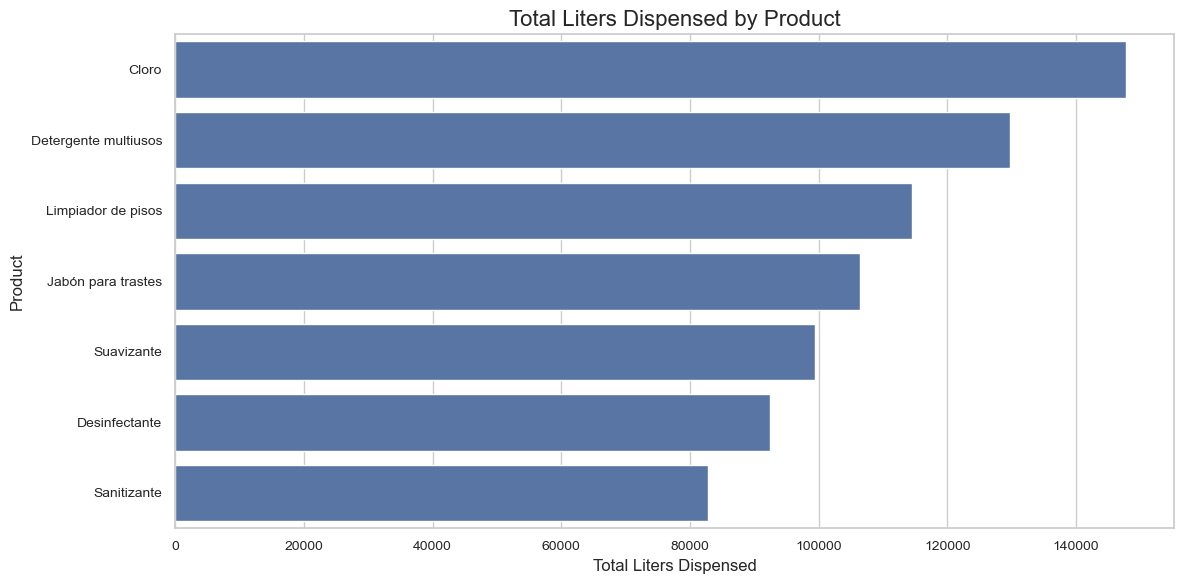

In [34]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=product_consumption,
    x="total_liters_dispensed",
    y="product_name"
)

plt.title("Total Liters Dispensed by Product")
plt.xlabel("Total Liters Dispensed")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [35]:
# Automatic insight
top_product = product_consumption.iloc[0]
bottom_product = product_consumption.iloc[-1]

print(
    f"Top rotating product: {top_product['product_name']} "
    f"with {top_product['total_liters_dispensed']:.2f} L dispensed."
)

print(
    f"Lowest rotating product: {bottom_product['product_name']} "
    f"with {bottom_product['total_liters_dispensed']:.2f} L dispensed."
)

Top rotating product: Cloro with 147862.16 L dispensed.
Lowest rotating product: Sanitizante with 82793.32 L dispensed.


### Business Insight

The product rotation analysis shows which products drive the highest inventory movement.

Products with stronger rotation should be prioritized in refill planning because they have a higher probability of reaching low inventory levels or creating stockout risk.

Low-rotation products should be reviewed to determine whether they need better visibility, promotional support, price adjustment, or replacement within the vending machine assortment.

## 13. Average Daily Consumption by Product

Total product consumption is useful, but average daily consumption provides a stronger operational metric.

This view helps estimate how quickly each product is consumed on a typical day and supports refill frequency planning.

In [36]:
# Daily product consumption
daily_product_consumption = (
    df.groupby(["date", "product_name"], as_index=False)
    .agg(daily_liters_dispensed=("liters_dispensed_l", "sum"))
)

# Average daily consumption by product
avg_daily_product_consumption = (
    daily_product_consumption
    .groupby("product_name", as_index=False)
    .agg(avg_daily_liters_dispensed=("daily_liters_dispensed", "mean"))
    .sort_values("avg_daily_liters_dispensed", ascending=False)
)

avg_daily_product_consumption

,product_name,avg_daily_liters_dispensed
0,Cloro,405.10
2,Detergente multiusos,355.60
4,Limpiador de pisos,313.62
3,Jabón para trastes,291.47
6,Suavizante,272.56
1,Desinfectante,253.38
5,Sanitizante,226.83


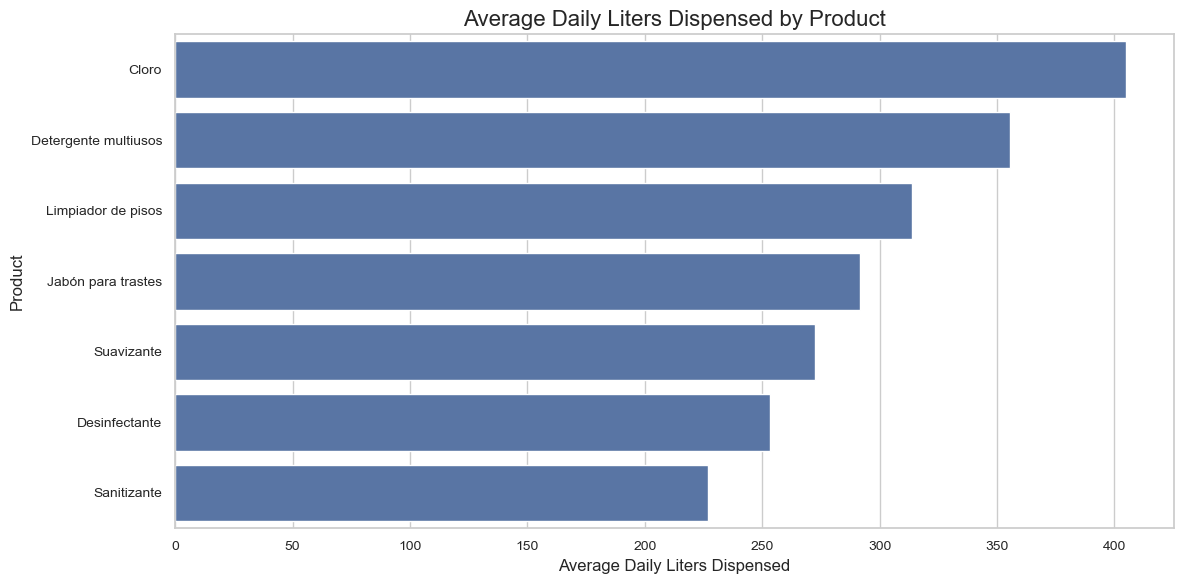

In [37]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=avg_daily_product_consumption,
    x="avg_daily_liters_dispensed",
    y="product_name"
)

plt.title("Average Daily Liters Dispensed by Product")
plt.xlabel("Average Daily Liters Dispensed")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Business Insight

Average daily consumption helps convert demand behavior into operational planning.

Products with higher daily consumption may require more frequent refills or higher safety stock levels. Products with lower daily consumption may not require the same refill priority.

This analysis helps avoid treating all products equally when their demand patterns are different.

## 14. Machine-Level Consumption Analysis

This section compares total liters dispensed across vending machines.

The objective is to identify which machines or locations generate stronger product movement and may require more operational attention.

In [38]:
# Consumption by machine
machine_consumption = (
    df.groupby("machine_id", as_index=False)
    .agg(total_liters_dispensed=("liters_dispensed_l", "sum"))
    .sort_values("total_liters_dispensed", ascending=False)
)

machine_consumption

,machine_id,total_liters_dispensed
60,VM-061,"15,299.58"
41,VM-042,"15,218.01"
71,VM-072,"14,521.14"
45,VM-046,"13,583.34"
47,VM-048,"13,503.67"
15,VM-016,"13,401.69"
22,VM-023,"13,335.11"
20,VM-021,"13,325.71"
51,VM-052,"13,271.22"
6,VM-007,"13,208.92"


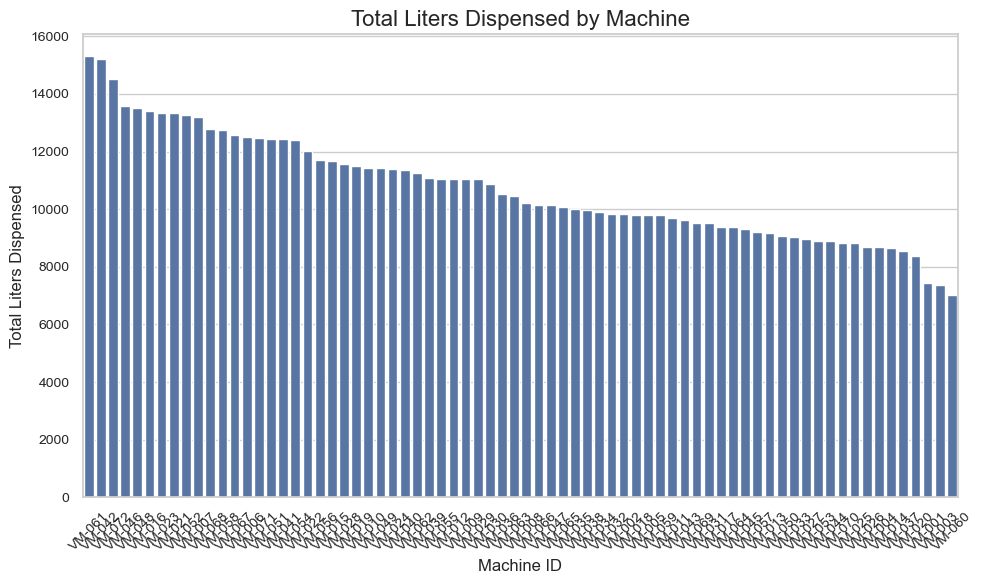

In [39]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=machine_consumption,
    x="machine_id",
    y="total_liters_dispensed"
)

plt.title("Total Liters Dispensed by Machine")
plt.xlabel("Machine ID")
plt.ylabel("Total Liters Dispensed")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Business Insight

Machine-level consumption reveals which vending machines have stronger demand.

Machines with higher consumption may require more frequent monitoring, faster refill cycles, and stronger inventory control. Machines with lower consumption may require commercial actions such as better signage, product mix adjustments, or location-level promotions.

This analysis helps prioritize operational resources across the vending network.

## 15. Product Consumption by Machine

This heatmap compares product consumption across machines.

It helps identify whether certain products perform consistently across the vending network or whether demand is location-specific.

In [40]:
# Product-machine consumption matrix
machine_product_matrix = df.pivot_table(
    index="product_name",
    columns="machine_id",
    values="liters_dispensed_l",
    aggfunc="sum",
    fill_value=0
)

machine_product_matrix

machine_id,VM-001,VM-002,VM-003,VM-004,VM-005,VM-006,VM-007,VM-008,VM-009,VM-010,VM-011,VM-012,VM-013,VM-014,VM-015,VM-016,VM-017,VM-018,VM-019,VM-020,VM-021,VM-022,VM-023,VM-024,VM-025,VM-026,VM-027,VM-028,VM-029,VM-030,VM-031,VM-032,VM-033,VM-034,VM-035,VM-036,VM-037,VM-038,VM-039,VM-040,VM-041,VM-042,VM-043,VM-044,VM-045,VM-046,VM-047,VM-048,VM-049,VM-050,VM-051,VM-052,VM-053,VM-054,VM-055,VM-056,VM-057,VM-058,VM-059,VM-060,VM-061,VM-062,VM-063,VM-064,VM-065,VM-066,VM-067,VM-068,VM-069,VM-070,VM-071,VM-072
product_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Cloro,"1,336.77","1,889.47","1,529.42","1,574.17","1,854.11","2,701.33","2,509.96","2,079.69","2,140.91","2,176.99","2,072.09","1,987.49","1,643.27","1,760.16","2,177.64","2,366.83","1,797.30","1,769.77","2,131.60","1,519.84","2,453.85","2,399.39","2,632.98","1,997.12","1,707.86","1,740.22","1,734.17","2,258.22","2,040.83","2,157.88","1,770.58","1,939.79","1,577.04","1,962.93","1,968.25","2,141.58","1,656.82","1,966.99","2,199.29","2,153.13","2,229.91","2,937.25","1,734.31","1,780.83","1,940.54","2,382.64","2,049.15","2,656.99","2,253.23","1,792.49","2,190.80","2,589.93","1,755.79","2,355.23","1,922.99","2,084.41","1,701.46","2,501.60","1,768.99","1,273.39","3,097.54","2,019.58","2,062.86","1,615.88","2,032.85","1,938.88","2,353.70","2,579.12","1,809.03","1,834.37","2,373.66","2,765.03"
Desinfectante,890.89,"1,098.99",868.85,983.96,"1,101.94","1,339.89","1,662.93","1,130.23","1,338.57","1,342.39","1,138.65","1,243.44","1,051.44",923.40,"1,458.91","1,659.26","1,045.88","1,113.35","1,520.00","1,053.02","1,694.30","1,420.43","1,512.86","1,305.00",916.84,"1,062.56",983.54,"1,305.32","1,419.50","1,296.45","1,235.02","1,214.86","1,117.60","1,110.92","1,296.94","1,104.17","1,057.34","1,092.86","1,282.35","1,445.29","1,460.92","1,725.60","1,236.52","1,075.15","1,076.97","1,783.59","1,348.95","1,536.05","1,432.00","1,083.56","1,573.27","1,566.96","1,061.30","1,663.62","1,308.41","1,376.98","1,012.21","1,664.69","1,153.16",806.58,"1,714.77","1,361.01","1,277.79","1,199.48","1,260.58","1,297.96","1,651.41","1,617.78","1,123.70","1,048.42","1,430.27","1,713.87"
Detergente multiusos,"1,309.80","1,700.43","1,273.81","1,544.73","1,756.14","1,956.51","2,122.21","1,718.13","1,899.58","1,761.78","1,746.44","1,907.41","1,583.22","1,396.96","2,069.16","2,271.75","1,601.30","1,541.02","2,161.35","1,402.09","2,174.55","2,112.76","2,074.32","2,015.91","1,502.84","1,371.09","1,514.30","1,855.31","1,779.38","1,869.44","1,592.98","1,618.08","1,519.90","1,576.20","1,554.17","1,743.20","1,428.47","1,743.20","1,939.68","1,891.50","2,208.97","2,733.04","1,634.23","1,485.83","1,531.74","2,219.60","1,810.07","2,117.21","1,991.82","1,484.52","2,280.59","2,222.80","1,491.28","1,966.00","1,983.08","2,042.63","1,457.45","2,071.55","1,560.81","1,161.87","2,333.21","1,935.64","1,685.02","1,664.55","1,674.80","1,566.34","2,189.83","2,164.42","1,693.43","1,429.95","1,900.50","2,499.36"
Jabón para trastes,975.03,"1,275.72",968.16,"1,245.32","1,493.88","1,741.13","1,749.71","1,390.67","1,529.49","1,634.04","1,301.21","1,453.15","1,124.38","1,247.19","1,510.84","1,997.48","1,246.55","1,549.78","1,393.36","1,109.96","1,941.40","1,501.48","1,885.60","1,652.86","1,314.60","1,280.74","1,306.87","1,666.46","1,505.25","1,548.87","1,218.59","1,354.26","1,332.57","1,348.93","1,393.94","1,482.04","1,264.27","1,272.80","1,440.12","1,558.47","1,635.28","1,964.30","1,247.19","1,149.67","1,214.52","1,894.78","1,331.24","1,900.10","1,567.93","1,172.22","1,547.18","1,843.29","1,204.98","1,593.29","1,553.02","1,564.42","1,233.40","1,676.35","1,411.97",963.76,"2,179.26","1,573.67","1,567.44","1,336.78","1,395.02","1,447.74","1,832.02","1,950.62","1,285.10","1,167.45","1,717.11","2,057.29"
Limpiador de pisos,"1,124.31","1,574.71","1,080.26","1,203.54","1,422.33","1,741.21","2,101.87","1,368.50","1,561.02","1,804.63","1,386.09","1,668.44","1,492.55","1,265.84","1,682.74","2,081.68","1,496.15","1,560

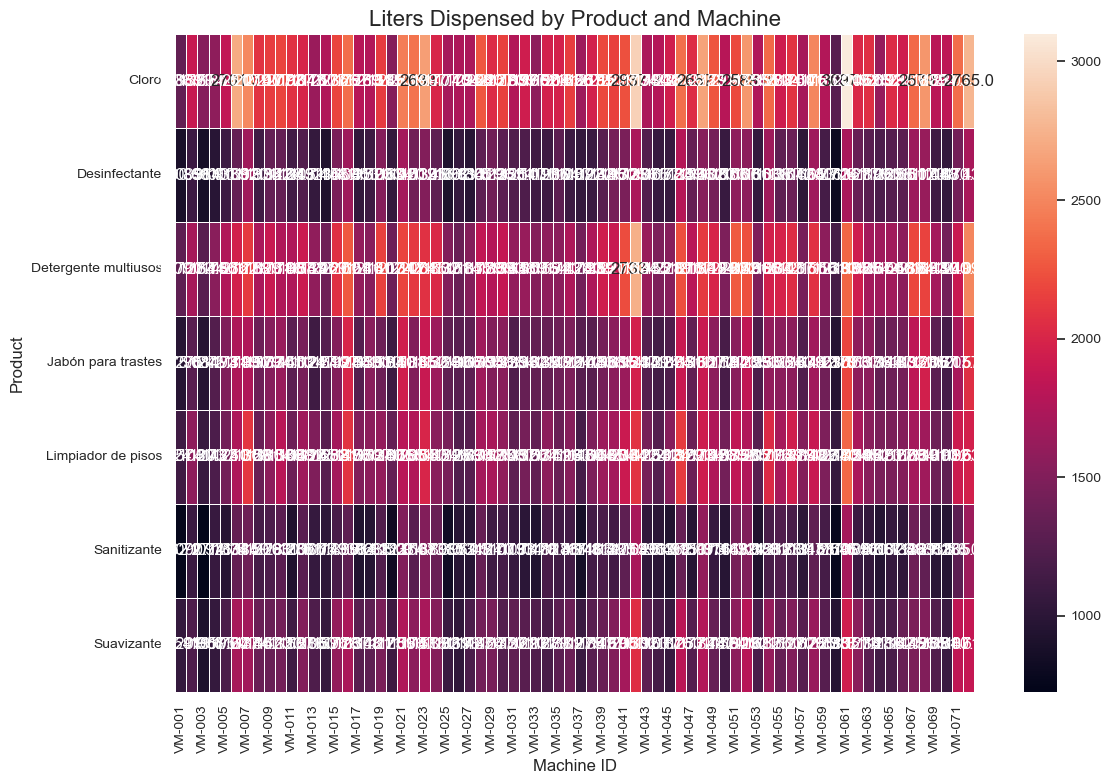

In [41]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    machine_product_matrix,
    annot=True,
    fmt=".1f",
    linewidths=0.5
)

plt.title("Liters Dispensed by Product and Machine")
plt.xlabel("Machine ID")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Business Insight

The heatmap shows how product demand varies by machine.

Higher values indicate stronger product movement for a specific product-machine combination. This is useful for tailoring refill plans and product assortment by location instead of applying the same operational strategy across all machines.

This type of analysis supports a more data-driven vending operation.

## 16. Refill Analysis

This section analyzes refill behavior by product.

The objective is to understand which products require more replenishment and whether refill activity aligns with actual product consumption.

In [42]:
# Refill behavior by product
product_refills = (
    df.groupby("product_name", as_index=False)
    .agg(
        total_liters_refilled=("liters_refilled_l", "sum"),
        refill_events=("refill_event", "sum"),
        total_liters_dispensed=("liters_dispensed_l", "sum")
    )
    .sort_values("total_liters_refilled", ascending=False)
)

product_refills

,product_name,total_liters_refilled,refill_events,total_liters_dispensed
0,Cloro,"147,531.57",2966,"147,862.16"
2,Detergente multiusos,"129,400.14",2529,"129,793.24"
4,Limpiador de pisos,"114,121.36",2250,"114,470.66"
3,Jabón para trastes,"105,949.45",2020,"106,385.56"
6,Suavizante,"99,089.15",1932,"99,486.14"
1,Desinfectante,"92,032.36",1739,"92,483.67"
5,Sanitizante,"82,409.66",1531,"82,793.32"


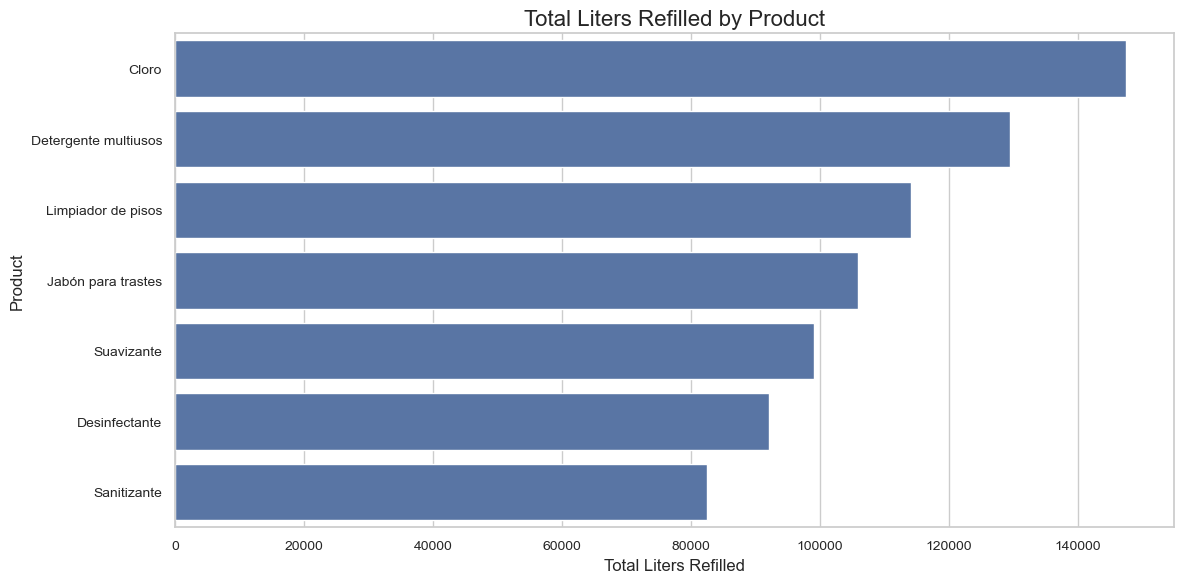

In [43]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=product_refills,
    x="total_liters_refilled",
    y="product_name"
)

plt.title("Total Liters Refilled by Product")
plt.xlabel("Total Liters Refilled")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [44]:
# Refill-to-consumption ratio
product_refills["refill_to_consumption_ratio"] = (
    product_refills["total_liters_refilled"] / 
    product_refills["total_liters_dispensed"]
).replace([np.inf, -np.inf], np.nan)

product_refills.sort_values("refill_to_consumption_ratio", ascending=False)

,product_name,total_liters_refilled,refill_events,total_liters_dispensed,refill_to_consumption_ratio
0,Cloro,"147,531.57",2966,"147,862.16",1.00
2,Detergente multiusos,"129,400.14",2529,"129,793.24",1.00
4,Limpiador de pisos,"114,121.36",2250,"114,470.66",1.00
6,Suavizante,"99,089.15",1932,"99,486.14",1.00
3,Jabón para trastes,"105,949.45",2020,"106,385.56",1.00
5,Sanitizante,"82,409.66",1531,"82,793.32",1.00
1,Desinfectante,"92,032.36",1739,"92,483.67",1.00


### Business Insight

Refill analysis helps determine whether operational effort is concentrated on the right products.

Products with high refill volume usually have stronger demand or higher consumption velocity. However, refill activity should be compared against actual liters dispensed to detect potential over-refilling, inefficient refill schedules, or mismatches between inventory planning and customer demand.

## 17. Inventory Fill Percentage Distribution

Inventory fill percentage shows how full each tank is at the end of each day.

This metric helps evaluate whether products are operating with healthy inventory levels or frequently ending the day close to empty.

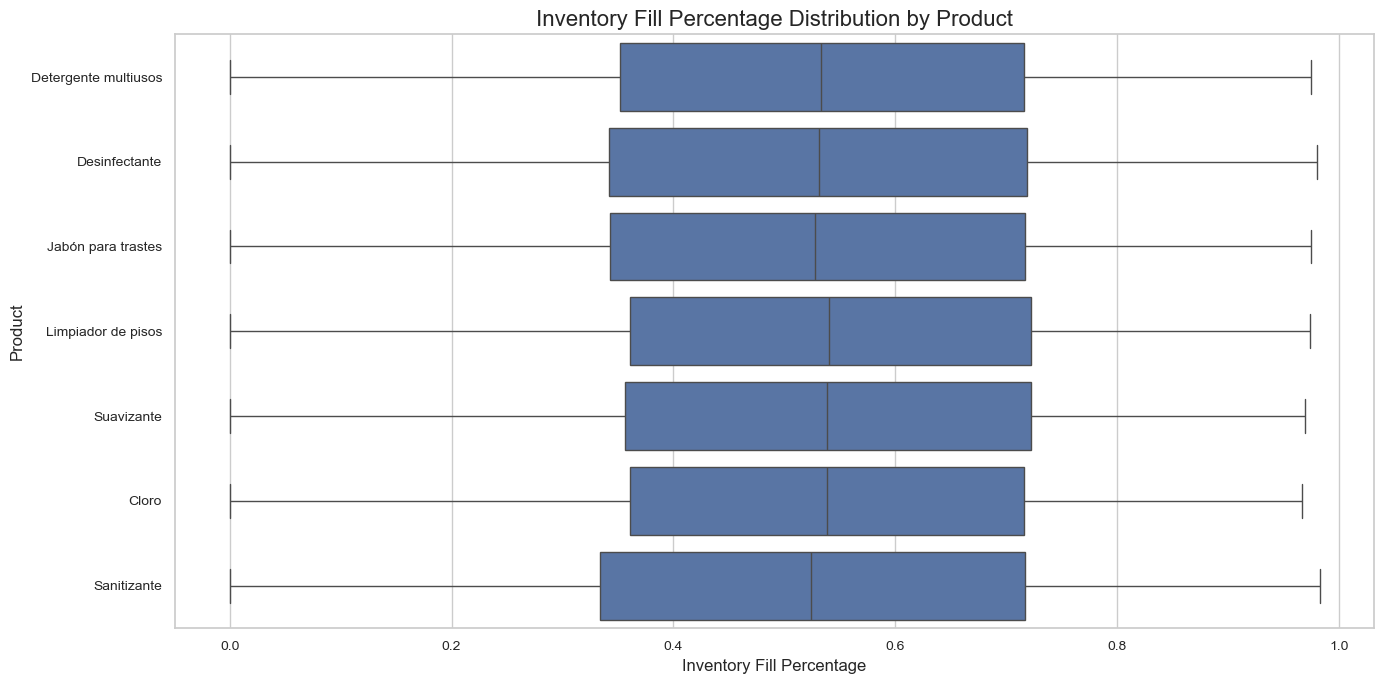

In [45]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df,
    x="inventory_fill_pct",
    y="product_name"
)

plt.title("Inventory Fill Percentage Distribution by Product")
plt.xlabel("Inventory Fill Percentage")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [46]:
# Average inventory fill percentage by product
avg_fill_by_product = (
    df.groupby("product_name", as_index=False)
    .agg(avg_inventory_fill_pct=("inventory_fill_pct", "mean"))
    .sort_values("avg_inventory_fill_pct")
)

avg_fill_by_product

,product_name,avg_inventory_fill_pct
5,Sanitizante,0.53
3,Jabón para trastes,0.53
1,Desinfectante,0.53
2,Detergente multiusos,0.53
0,Cloro,0.54
6,Suavizante,0.54
4,Limpiador de pisos,0.54


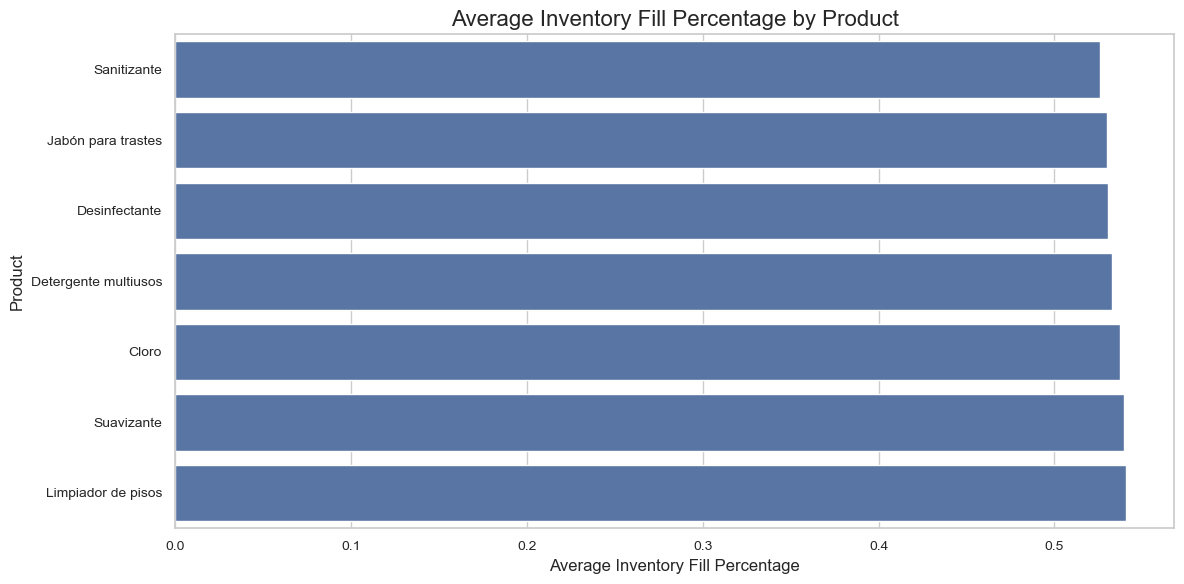

In [47]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=avg_fill_by_product,
    x="avg_inventory_fill_pct",
    y="product_name"
)

plt.title("Average Inventory Fill Percentage by Product")
plt.xlabel("Average Inventory Fill Percentage")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Business Insight

Inventory fill percentage helps identify products that frequently operate with low inventory levels.

Products with lower median fill percentage may be at higher stockout risk, especially if they also have high daily consumption. Products with consistently high fill percentage may be overstocked or may have lower rotation.

This insight supports better tank capacity planning and refill prioritization.

## 18. Reorder Risk Analysis

A reorder risk event occurs when closing inventory is equal to or below the reorder point.

This analysis helps identify products that frequently require operational attention before they become stockout events.

In [48]:
# Reorder risk by product
reorder_risk_by_product = (
    df.groupby("product_name", as_index=False)
    .agg(
        reorder_risk_events=("reorder_risk_event", "sum"),
        total_records=("reorder_risk_event", "count")
    )
)

reorder_risk_by_product["reorder_risk_rate"] = (
    reorder_risk_by_product["reorder_risk_events"] / 
    reorder_risk_by_product["total_records"]
)

reorder_risk_by_product = reorder_risk_by_product.sort_values(
    "reorder_risk_rate",
    ascending=False
)

reorder_risk_by_product

,product_name,reorder_risk_events,total_records,reorder_risk_rate
0,Cloro,3724,26280,0.14
2,Detergente multiusos,3148,26280,0.12
4,Limpiador de pisos,2788,26280,0.11
3,Jabón para trastes,2525,26280,0.10
6,Suavizante,2441,26280,0.09
1,Desinfectante,2157,26280,0.08
5,Sanitizante,1938,26280,0.07


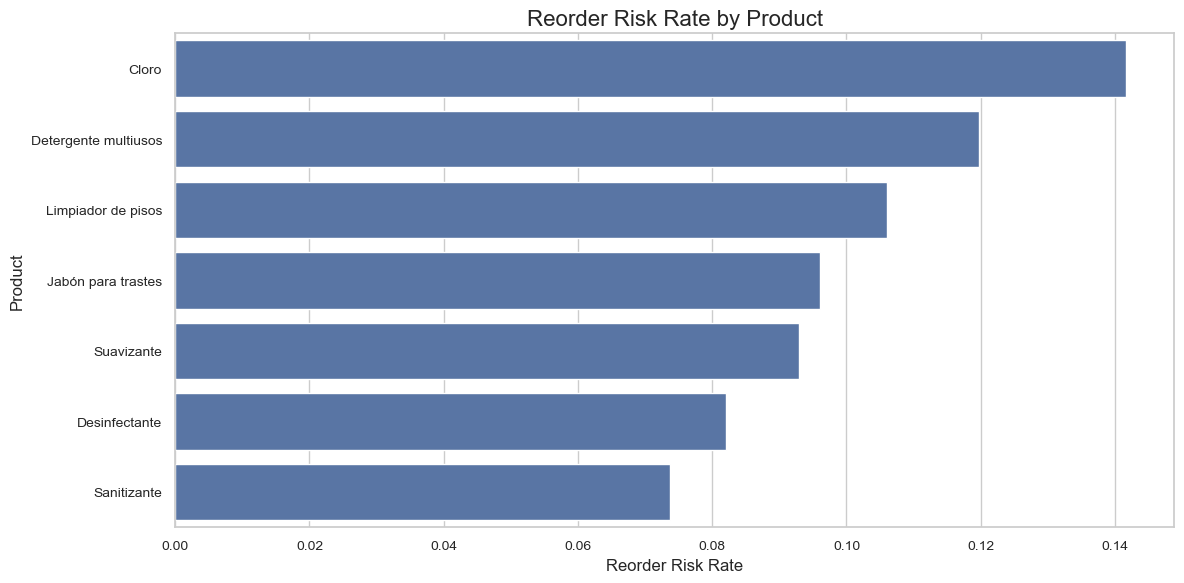

In [49]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=reorder_risk_by_product,
    x="reorder_risk_rate",
    y="product_name"
)

plt.title("Reorder Risk Rate by Product")
plt.xlabel("Reorder Risk Rate")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Business Insight

The reorder risk rate shows how often each product closes the day at or below its reorder point.

Products with high reorder risk should be monitored more closely because they are more likely to become stockout events if refills are delayed.

This metric is especially useful for creating operational alerts and defining refill priorities.

## 19. Stockout Analysis

Stockouts represent moments when the vending machine cannot satisfy demand because inventory is unavailable.

This section analyzes stockout exposure by product and machine.

In [50]:
# Stockout by product
stockout_by_product = (
    df.groupby("product_name", as_index=False)
    .agg(
        stockout_events=("stockout_event", "sum"),
        total_stockout_minutes=("stockout_minutes", "sum")
    )
    .sort_values("total_stockout_minutes", ascending=False)
)

stockout_by_product

,product_name,stockout_events,total_stockout_minutes
2,Detergente multiusos,61,24069
0,Cloro,48,17921
6,Suavizante,22,9667
4,Limpiador de pisos,21,7353
3,Jabón para trastes,17,6983
1,Desinfectante,14,5663
5,Sanitizante,18,5372


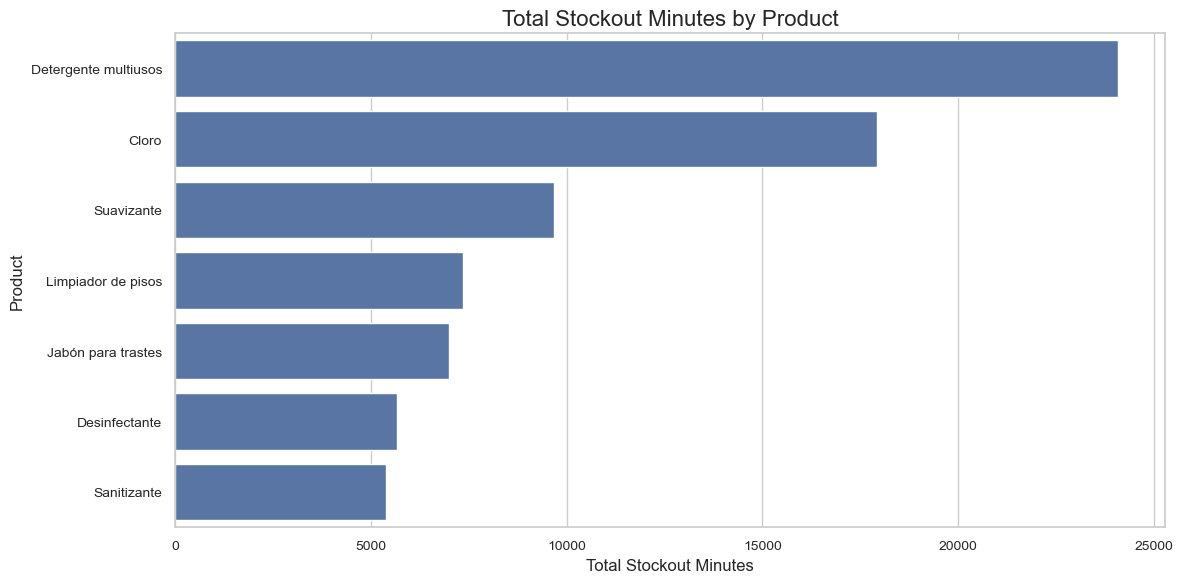

In [51]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=stockout_by_product,
    x="total_stockout_minutes",
    y="product_name"
)

plt.title("Total Stockout Minutes by Product")
plt.xlabel("Total Stockout Minutes")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [52]:
# Stockout by machine
stockout_by_machine = (
    df.groupby("machine_id", as_index=False)
    .agg(
        stockout_events=("stockout_event", "sum"),
        total_stockout_minutes=("stockout_minutes", "sum")
    )
    .sort_values("total_stockout_minutes", ascending=False)
)

stockout_by_machine

,machine_id,stockout_events,total_stockout_minutes
71,VM-072,14,6624
40,VM-041,11,6548
41,VM-042,12,5961
21,VM-022,8,4602
64,VM-065,7,4199
22,VM-023,7,3720
67,VM-068,7,3239
51,VM-052,9,2981
66,VM-067,6,2671
70,VM-071,5,2670


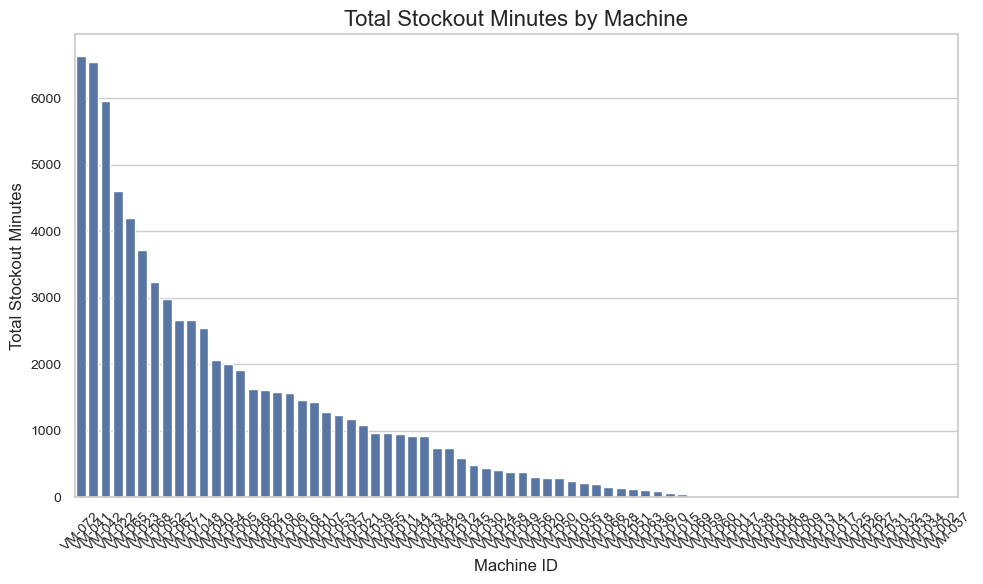

In [53]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=stockout_by_machine,
    x="machine_id",
    y="total_stockout_minutes"
)

plt.title("Total Stockout Minutes by Machine")
plt.xlabel("Machine ID")
plt.ylabel("Total Stockout Minutes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Business Insight

Stockout minutes are one of the most important operational risk indicators because they can represent lost sales opportunities.

Products or machines with higher stockout minutes should be prioritized for refill optimization, reorder point adjustment, or capacity review.

From a business perspective, reducing stockout time can directly improve product availability and revenue potential.

## 20. Stockout Heatmap by Product and Machine

This heatmap shows where stockout minutes are concentrated.

It helps identify whether stockout risk is product-specific, machine-specific, or concentrated in specific product-machine combinations.

In [54]:
# Stockout matrix
stockout_matrix = df.pivot_table(
    index="product_name",
    columns="machine_id",
    values="stockout_minutes",
    aggfunc="sum",
    fill_value=0
)

stockout_matrix

machine_id,VM-001,VM-002,VM-003,VM-004,VM-005,VM-006,VM-007,VM-008,VM-009,VM-010,VM-011,VM-012,VM-013,VM-014,VM-015,VM-016,VM-017,VM-018,VM-019,VM-020,VM-021,VM-022,VM-023,VM-024,VM-025,VM-026,VM-027,VM-028,VM-029,VM-030,VM-031,VM-032,VM-033,VM-034,VM-035,VM-036,VM-037,VM-038,VM-039,VM-040,VM-041,VM-042,VM-043,VM-044,VM-045,VM-046,VM-047,VM-048,VM-049,VM-050,VM-051,VM-052,VM-053,VM-054,VM-055,VM-056,VM-057,VM-058,VM-059,VM-060,VM-061,VM-062,VM-063,VM-064,VM-065,VM-066,VM-067,VM-068,VM-069,VM-070,VM-071,VM-072
product_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Cloro,0,0,0,0,0,257,777,0,0,0,0,0,0,0,0,1126,0,203,0,295,448,701,1167,0,0,0,0,47,0,437,0,0,0,0,0,41,0,0,859,1168,0,1676,0,111,0,0,0,0,365,295,0,0,780,100,972,0,0,0,0,0,54,0,0,0,0,0,1813,1136,0,0,1744,1349
Desinfectante,0,0,0,0,0,0,448,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,726,0,0,0,0,90,0,0,0,0,0,0,212,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,465,0,1291,0,0,0,0,0,0,0,0,0,0,1664,159,260,348,0,0,0,0
Detergente multiusos,0,0,0,0,536,0,0,0,0,0,0,0,0,0,46,25,0,0,625,0,172,2091,0,0,0,0,0,0,124,0,0,0,0,0,0,49,0,0,0,549,4313,3056,0,0,0,1355,0,0,13,0,100,1508,456,0,0,126,1173,0,0,0,881,1101,106,0,2535,0,219,598,0,71,0,2241
Jabón para trastes,0,0,0,0,1381,105,0,0,0,0,949,0,0,0,0,0,0,0,0,0,44,0,1523,0,0,0,0,0,553,0,0,0,0,0,0,0,0,0,0,0,0,1201,0,0,485,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,742,0,0,0,0,0,0,0,0
Limpiador de pisos,0,0,0,0,0,0,0,0,0,251,0,592,0,0,0,0,0,0,0,0,0,0,304,385,0,0,0,0,60,0,0,0,0,0,0,0,0,0,115,346,118,0,0,0,0,0,0,626,0,0,0,868,0,614,0,174,0,0,0,0,0,0,0,0,0,0,379,1157,0,0,926,438
Sanitizante,0,0,0,0,0,0,57,0,0,0,0,0,0,0,0,0,0,0,0,0,363,1491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28,0,0,0,95,0,1917,0,0,31,140,0,0,0,0,0,0,0,0,501,0,0,0,0,0,0,0,0,0,0,749
Suavizante,0,0,0,0,0,1213,0,0,0,0,0,0,0,0,0,311,0,0,958,0,62,319,0,23,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2117,0,922,818,0,177,0,0,0,0,0,0,0,0,0,0,0,383,0,0,0,517,0,0,0,0,0,0,0,0,0,1847


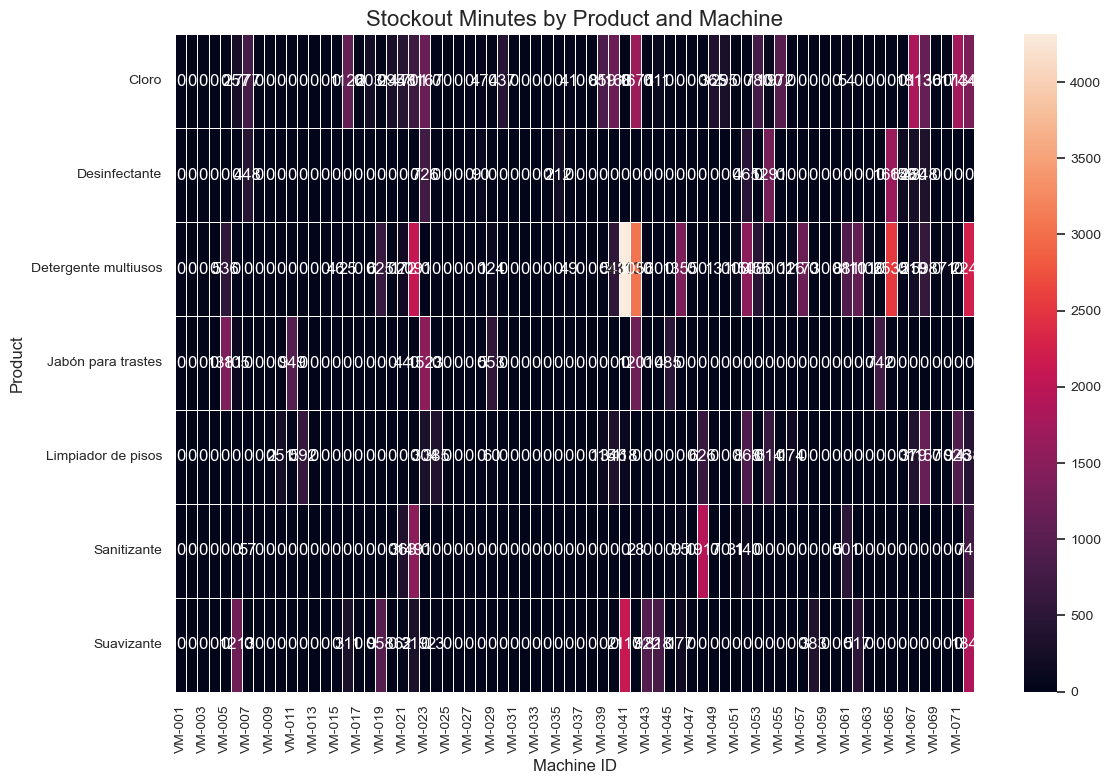

In [55]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    stockout_matrix,
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Stockout Minutes by Product and Machine")
plt.xlabel("Machine ID")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Business Insight

The stockout heatmap identifies the most critical product-machine combinations.

A high stockout value in a specific cell suggests that the issue may not be general across the network, but concentrated in one location or product.

This allows the business to act with precision instead of applying broad operational changes across every machine or product.

## 21. Consumption vs. Reorder Risk

This section compares product consumption against reorder risk.

The objective is to identify products that combine high demand with high inventory risk.

These products should be considered operational priorities.

In [56]:
# Product-level operational summary
product_operational_summary = (
    df.groupby("product_name", as_index=False)
    .agg(
        total_liters_dispensed=("liters_dispensed_l", "sum"),
        avg_daily_inventory_fill_pct=("inventory_fill_pct", "mean"),
        reorder_risk_events=("reorder_risk_event", "sum"),
        stockout_events=("stockout_event", "sum"),
        total_stockout_minutes=("stockout_minutes", "sum")
    )
)

product_operational_summary

,product_name,total_liters_dispensed,avg_daily_inventory_fill_pct,reorder_risk_events,stockout_events,total_stockout_minutes
0,Cloro,"147,862.16",0.54,3724,48,17921
1,Desinfectante,"92,483.67",0.53,2157,14,5663
2,Detergente multiusos,"129,793.24",0.53,3148,61,24069
3,Jabón para trastes,"106,385.56",0.53,2525,17,6983
4,Limpiador de pisos,"114,470.66",0.54,2788,21,7353
5,Sanitizante,"82,793.32",0.53,1938,18,5372
6,Suavizante,"99,486.14",0.54,2441,22,9667


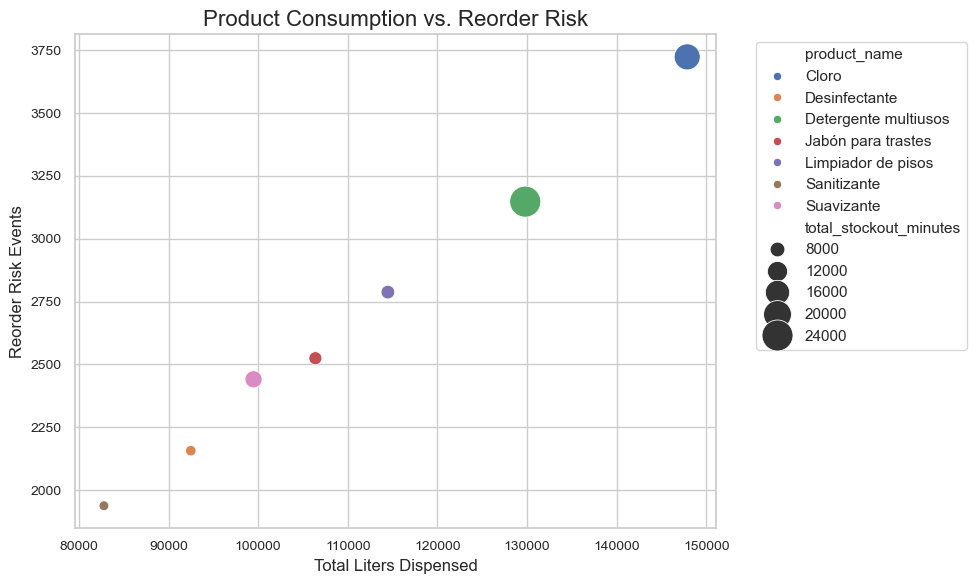

In [57]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=product_operational_summary,
    x="total_liters_dispensed",
    y="reorder_risk_events",
    size="total_stockout_minutes",
    hue="product_name",
    sizes=(50, 500)
)

plt.title("Product Consumption vs. Reorder Risk")
plt.xlabel("Total Liters Dispensed")
plt.ylabel("Reorder Risk Events")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Business Insight

This chart helps identify operational priority products.

Products located toward the upper-right area combine high consumption with high reorder risk. These products are especially important because they may generate strong demand but also require tighter inventory control.

If a product has high consumption, high reorder risk, and high stockout minutes, it should be considered a priority for refill planning, safety stock adjustment, or tank capacity review.

## 22. Portfolio-Level Operational Summary

This section consolidates the main operational indicators at product level.

The objective is to move from isolated charts to a business-oriented summary that identifies which products represent the highest operational priority based on:

- Total liters dispensed
- Consumption share
- Reorder risk events
- Stockout events
- Stockout minutes
- Stockout exposure share

This summary helps determine which products require closer monitoring, better refill planning, or possible tank capacity adjustments.

In [58]:
# Product-level portfolio summary
product_portfolio_summary = (
    df.groupby("product_name", as_index=False)
    .agg(
        total_liters_dispensed=("liters_dispensed_l", "sum"),
        total_liters_refilled=("liters_refilled_l", "sum"),
        avg_inventory_fill_pct=("inventory_fill_pct", "mean"),
        reorder_risk_events=("reorder_risk_event", "sum"),
        refill_events=("refill_event", "sum"),
        stockout_events=("stockout_event", "sum"),
        total_stockout_minutes=("stockout_minutes", "sum"),
        total_records=("product_name", "count")
    )
)

# Additional portfolio metrics
product_portfolio_summary["consumption_share_pct"] = (
    product_portfolio_summary["total_liters_dispensed"] /
    product_portfolio_summary["total_liters_dispensed"].sum()
)

product_portfolio_summary["stockout_minutes_share_pct"] = (
    product_portfolio_summary["total_stockout_minutes"] /
    product_portfolio_summary["total_stockout_minutes"].sum()
)

product_portfolio_summary["reorder_risk_rate"] = (
    product_portfolio_summary["reorder_risk_events"] /
    product_portfolio_summary["total_records"]
)

product_portfolio_summary["stockout_hours"] = (
    product_portfolio_summary["total_stockout_minutes"] / 60
)

product_portfolio_summary = product_portfolio_summary.sort_values(
    by="total_liters_dispensed",
    ascending=False
)

product_portfolio_summary

,product_name,total_liters_dispensed,total_liters_refilled,avg_inventory_fill_pct,reorder_risk_events,refill_events,stockout_events,total_stockout_minutes,total_records,consumption_share_pct,stockout_minutes_share_pct,reorder_risk_rate,stockout_hours
0,Cloro,"147,862.16","147,531.57",0.54,3724,2966,48,17921,26280,0.19,0.23,0.14,298.68
2,Detergente multiusos,"129,793.24","129,400.14",0.53,3148,2529,61,24069,26280,0.17,0.31,0.12,401.15
4,Limpiador de pisos,"114,470.66","114,121.36",0.54,2788,2250,21,7353,26280,0.15,0.10,0.11,122.55
3,Jabón para trastes,"106,385.56","105,949.45",0.53,2525,2020,17,6983,26280,0.14,0.09,0.10,116.38
6,Suavizante,"99,486.14","99,089.15",0.54,2441,1932,22,9667,26280,0.13,0.13,0.09,161.12
1,Desinfectante,"92,483.67","92,032.36",0.53,2157,1739,14,5663,26280,0.12,0.07,0.08,94.38
5,Sanitizante,"82,793.32","82,409.66",0.53,1938,1531,18,5372,26280,0.11,0.07,0.07,89.53


In [59]:
# Format selected percentage columns for readability
product_portfolio_display = product_portfolio_summary.copy()

percentage_columns = [
    "avg_inventory_fill_pct",
    "consumption_share_pct",
    "stockout_minutes_share_pct",
    "reorder_risk_rate"
]

for col in percentage_columns:
    product_portfolio_display[col] = product_portfolio_display[col].apply(lambda x: f"{x:.2%}")

product_portfolio_display

,product_name,total_liters_dispensed,total_liters_refilled,avg_inventory_fill_pct,reorder_risk_events,refill_events,stockout_events,total_stockout_minutes,total_records,consumption_share_pct,stockout_minutes_share_pct,reorder_risk_rate,stockout_hours
0,Cloro,"147,862.16","147,531.57",53.74%,3724,2966,48,17921,26280,19.12%,23.27%,14.17%,298.68
2,Detergente multiusos,"129,793.24","129,400.14",53.29%,3148,2529,61,24069,26280,16.78%,31.25%,11.98%,401.15
4,Limpiador de pisos,"114,470.66","114,121.36",54.10%,2788,2250,21,7353,26280,14.80%,9.55%,10.61%,122.55
3,Jabón para trastes,"106,385.56","105,949.45",52.98%,2525,2020,17,6983,26280,13.76%,9.07%,9.61%,116.38
6,Suavizante,"99,486.14","99,089.15",53.94%,2441,1932,22,9667,26280,12.87%,12.55%,9.29%,161.12
1,Desinfectante,"92,483.67","92,032.36",53.04%,2157,1739,14,5663,26280,11.96%,7.35%,8.21%,94.38
5,Sanitizante,"82,793.32","82,409.66",52.59%,1938,1531,18,5372,26280,10.71%,6.97%,7.37%,89.53


### Portfolio Insight

The product-level portfolio summary helps identify which products create the greatest operational pressure.

A product should be considered high priority when it combines:

1. High liters dispensed
2. High reorder risk
3. High stockout minutes
4. High stockout share relative to its consumption share

This approach is more useful than looking only at sales volume because it connects demand with operational risk.

## 23. Product Priority Matrix

This visualization compares product demand against stockout exposure.

Products with high consumption and high stockout minutes should be treated as operational priorities because they combine strong demand with product availability risk.

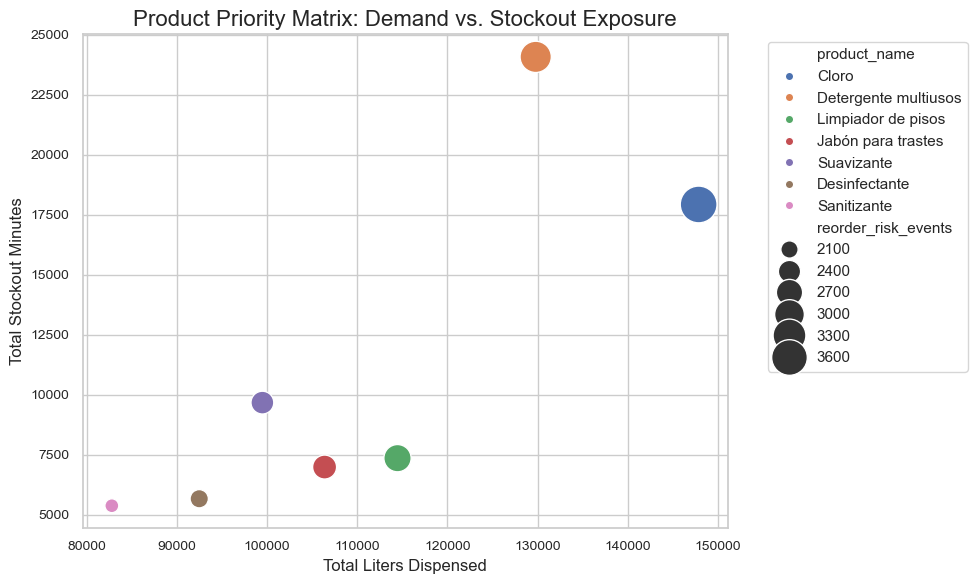

In [60]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=product_portfolio_summary,
    x="total_liters_dispensed",
    y="total_stockout_minutes",
    size="reorder_risk_events",
    hue="product_name",
    sizes=(100, 700)
)

plt.title("Product Priority Matrix: Demand vs. Stockout Exposure")
plt.xlabel("Total Liters Dispensed")
plt.ylabel("Total Stockout Minutes")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Business Insight

The product priority matrix identifies which products require the most operational attention.

Products in the upper-right area of the chart combine high demand with high stockout exposure. These products should be prioritized for refill planning, reorder point adjustment, or tank capacity review.

Products with lower demand and lower stockout exposure may require less frequent monitoring or a different commercial strategy.

## 24. Refill Need vs. Actual Refill

This section compares refill need against actual refill activity.

The dataset includes `refill_needed_flag`, which indicates when inventory reached a level that required replenishment. Separately, `refill_event` was created from actual refill volume using `liters_refilled_l > 0`.

This comparison helps identify potential refill gaps where inventory required attention but no refill occurred on the same day.

In [61]:
# Create refill need event from the original dataset flag
df["refill_needed_event"] = df["refill_needed_flag"].astype(bool)

# Identify days where refill was needed but no actual refill occurred
df["needed_but_not_refilled"] = df["refill_needed_event"] & ~df["refill_event"]

# Summary by product
refill_gap_by_product = (
    df.groupby("product_name", as_index=False)
    .agg(
        refill_needed_days=("refill_needed_event", "sum"),
        actual_refill_events=("refill_event", "sum"),
        needed_but_not_refilled_days=("needed_but_not_refilled", "sum")
    )
)

refill_gap_by_product["refill_gap_rate"] = (
    refill_gap_by_product["needed_but_not_refilled_days"] /
    refill_gap_by_product["refill_needed_days"]
).replace([np.inf, -np.inf], np.nan)

refill_gap_by_product = refill_gap_by_product.sort_values(
    "needed_but_not_refilled_days",
    ascending=False
)

refill_gap_by_product

,product_name,refill_needed_days,actual_refill_events,needed_but_not_refilled_days,refill_gap_rate
0,Cloro,3717,2966,3717,1.00
2,Detergente multiusos,3143,2529,3143,1.00
4,Limpiador de pisos,2781,2250,2781,1.00
3,Jabón para trastes,2519,2020,2519,1.00
6,Suavizante,2438,1932,2438,1.00
1,Desinfectante,2149,1739,2149,1.00
5,Sanitizante,1935,1531,1935,1.00


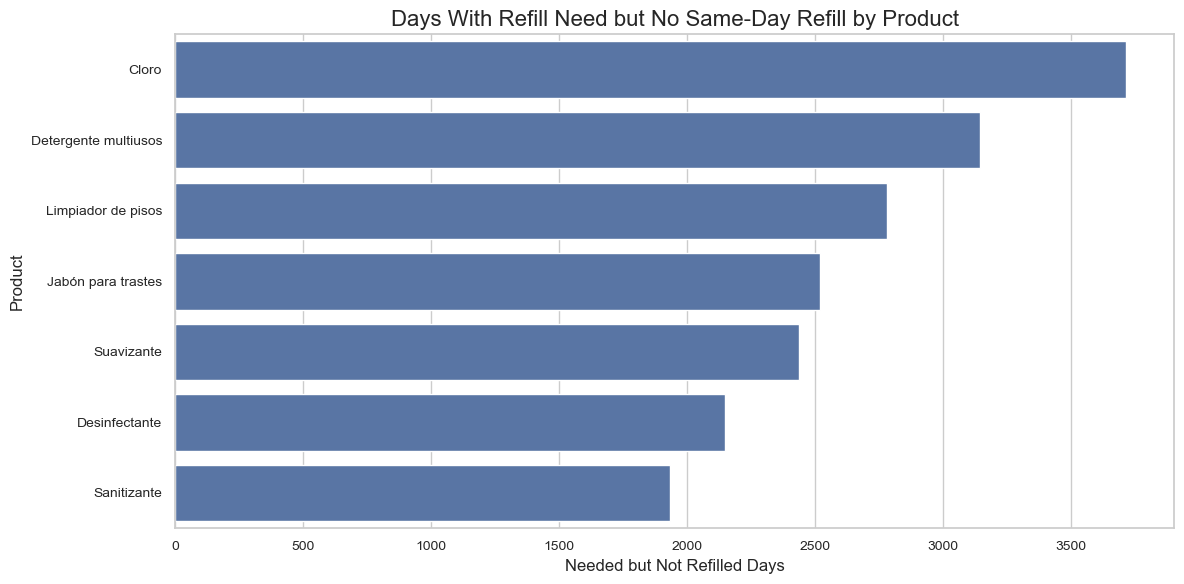

In [62]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=refill_gap_by_product,
    x="needed_but_not_refilled_days",
    y="product_name"
)

plt.title("Days With Refill Need but No Same-Day Refill by Product")
plt.xlabel("Needed but Not Refilled Days")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Business Insight

This analysis helps detect possible refill execution gaps.

A high number of days with refill need but no same-day refill may indicate that the refill schedule is not fully aligned with inventory risk signals.

This does not always mean an operational failure, because refills may occur the following day. However, it is a useful early warning metric for improving refill routes, service frequency, and inventory monitoring.

## 25. Location-Level Inventory Analysis

This section analyzes inventory movement by city and location type.

The objective is to identify where product demand and operational risk are concentrated.

This view helps determine whether refill planning should vary by geography or type of location.

In [63]:
# City-level operational summary
city_summary = (
    df.groupby("city", as_index=False)
    .agg(
        total_liters_dispensed=("liters_dispensed_l", "sum"),
        refill_events=("refill_event", "sum"),
        reorder_risk_events=("reorder_risk_event", "sum"),
        stockout_events=("stockout_event", "sum"),
        total_stockout_minutes=("stockout_minutes", "sum")
    )
)

city_summary["stockout_hours"] = city_summary["total_stockout_minutes"] / 60

city_summary = city_summary.sort_values(
    "total_liters_dispensed",
    ascending=False
)

city_summary

,city,total_liters_dispensed,refill_events,reorder_risk_events,stockout_events,total_stockout_minutes,stockout_hours
0,Ciudad de México,"198,250.41",3826,4799,59,23696,394.93
5,Puebla,"113,283.47",2202,2768,31,14962,249.37
3,Monterrey,"109,806.16",2118,2633,31,11273,187.88
1,Guadalajara,"88,345.28",1699,2139,26,9096,151.60
7,Tijuana,"80,200.14",1566,1923,12,4920,82.00
2,León,"66,961.42",1300,1614,18,6366,106.10
4,Mérida,"62,175.71",1203,1512,10,3733,62.22
6,Querétaro,"54,252.16",1053,1333,14,2982,49.70


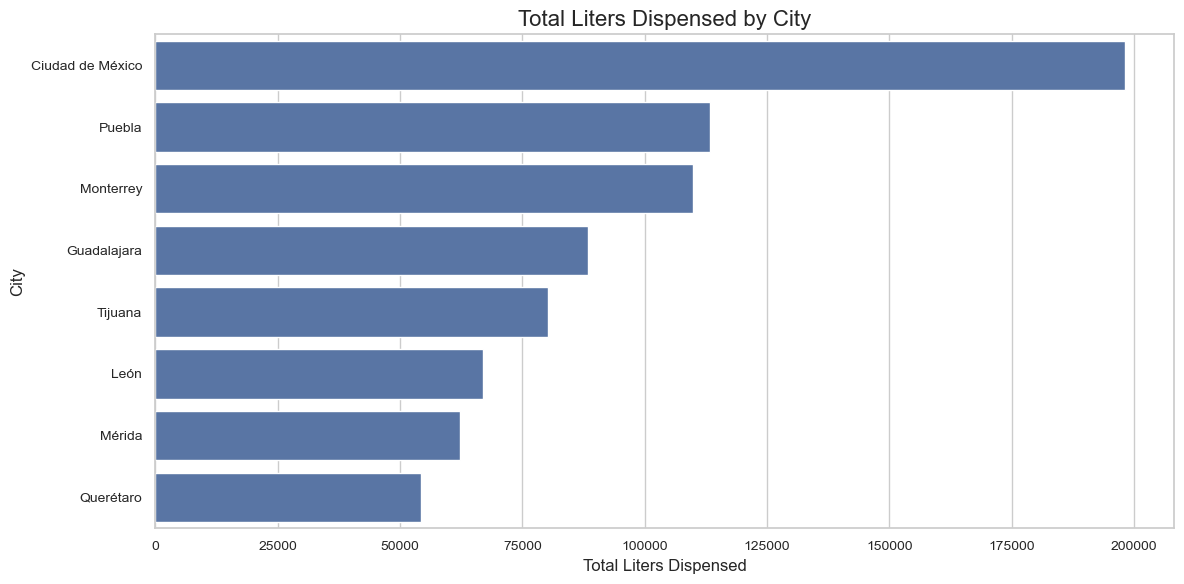

In [64]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=city_summary,
    x="total_liters_dispensed",
    y="city"
)

plt.title("Total Liters Dispensed by City")
plt.xlabel("Total Liters Dispensed")
plt.ylabel("City")
plt.tight_layout()
plt.show()

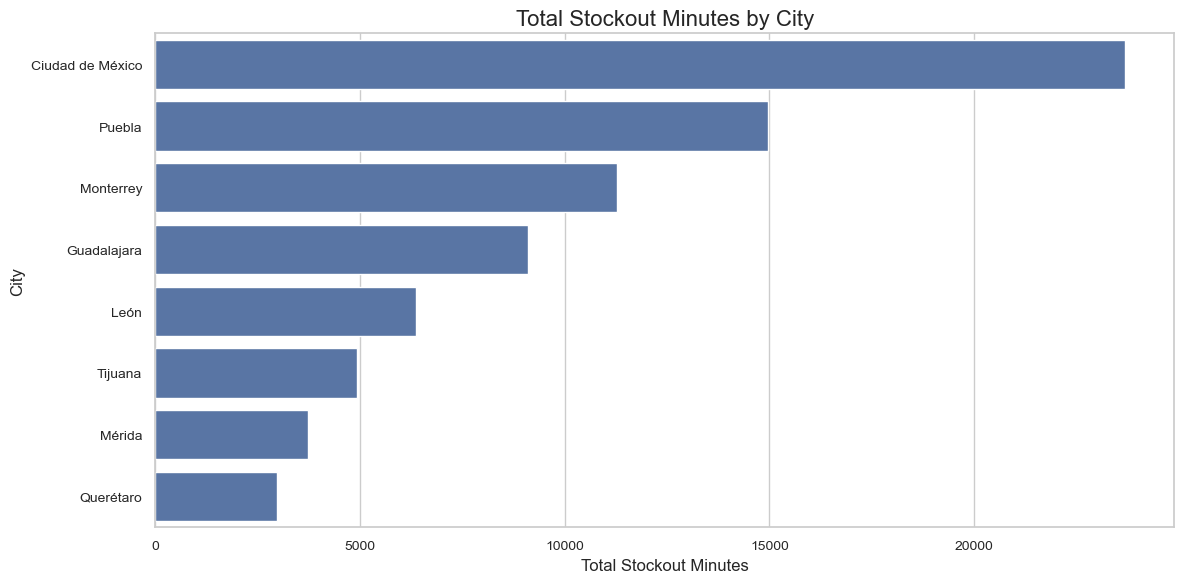

In [65]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=city_summary.sort_values("total_stockout_minutes", ascending=False),
    x="total_stockout_minutes",
    y="city"
)

plt.title("Total Stockout Minutes by City")
plt.xlabel("Total Stockout Minutes")
plt.ylabel("City")
plt.tight_layout()
plt.show()

### Business Insight

City-level analysis helps identify whether operational demand and stockout exposure are geographically concentrated.

Cities with high consumption should receive more frequent refill monitoring. Cities with high stockout minutes may require route optimization, higher safety stock, or faster response times.

This analysis supports a more scalable vending machine operation because it connects inventory decisions with geographic demand.

## 26. Location Type Analysis

This section compares inventory performance across different types of locations.

The goal is to understand whether demand behaves differently in hotels, hospitals, universities, offices, shopping centers, or industrial parks.

In [66]:
# Location type operational summary
location_type_summary = (
    df.groupby("location_type", as_index=False)
    .agg(
        total_liters_dispensed=("liters_dispensed_l", "sum"),
        refill_events=("refill_event", "sum"),
        reorder_risk_events=("reorder_risk_event", "sum"),
        stockout_events=("stockout_event", "sum"),
        total_stockout_minutes=("stockout_minutes", "sum")
    )
)

location_type_summary["stockout_hours"] = (
    location_type_summary["total_stockout_minutes"] / 60
)

location_type_summary = location_type_summary.sort_values(
    "total_liters_dispensed",
    ascending=False
)

location_type_summary

,location_type,total_liters_dispensed,refill_events,reorder_risk_events,stockout_events,total_stockout_minutes,stockout_hours
0,Centro comercial,"225,307.75",4310,5460,105,43596,726.60
4,Parque industrial,"136,271.87",2629,3265,35,10622,177.03
2,Hotel,"132,019.14",2590,3188,16,8219,136.98
3,Oficinas corporativas,"101,644.06",1977,2465,17,5210,86.83
1,Hospital,"89,108.34",1718,2136,16,5966,99.43
5,Universidad,"88,923.59",1743,2207,12,3415,56.92


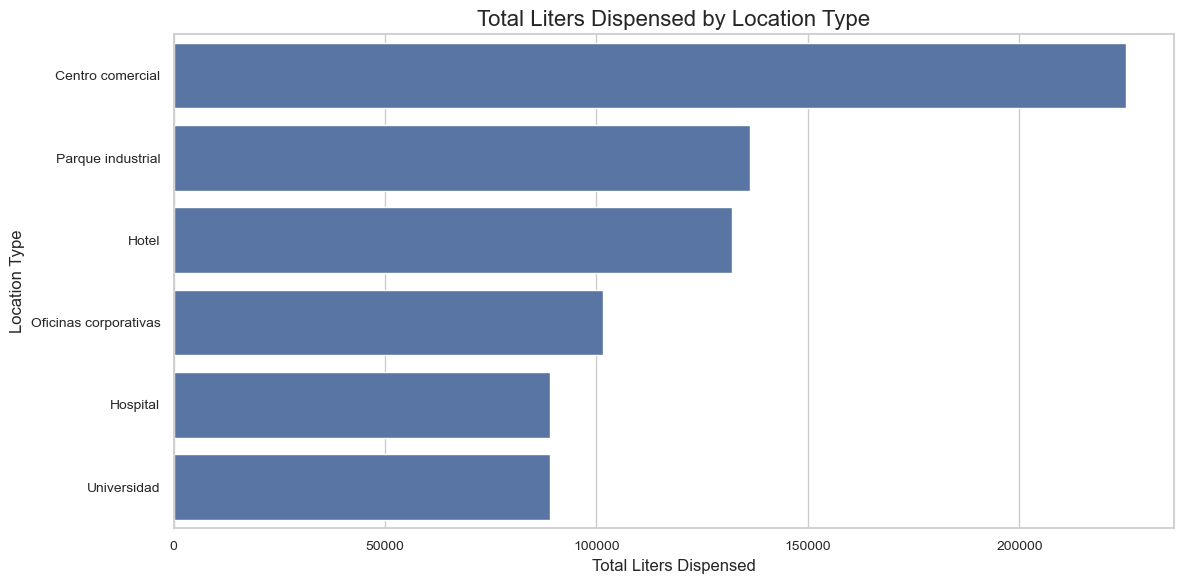

In [67]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=location_type_summary,
    x="total_liters_dispensed",
    y="location_type"
)

plt.title("Total Liters Dispensed by Location Type")
plt.xlabel("Total Liters Dispensed")
plt.ylabel("Location Type")
plt.tight_layout()
plt.show()

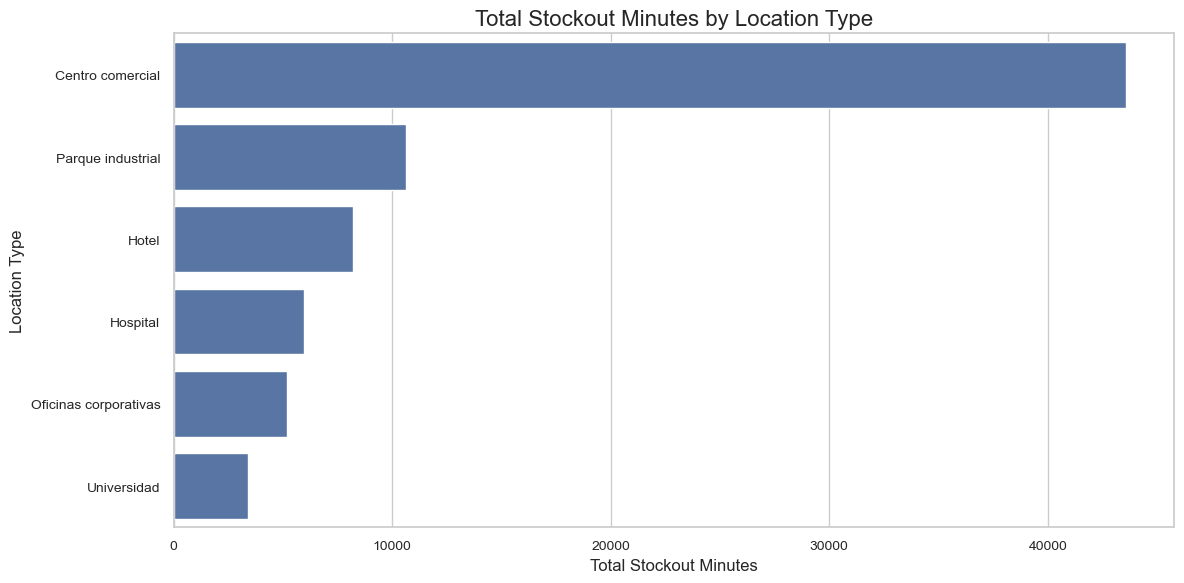

In [68]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=location_type_summary.sort_values("total_stockout_minutes", ascending=False),
    x="total_stockout_minutes",
    y="location_type"
)

plt.title("Total Stockout Minutes by Location Type")
plt.xlabel("Total Stockout Minutes")
plt.ylabel("Location Type")
plt.tight_layout()
plt.show()

### Business Insight

Location type analysis helps identify which environments create stronger product demand or higher operational risk.

If certain location types generate higher consumption, they may require more frequent refill cycles. If certain location types generate more stockout minutes, they may need adjusted reorder points or higher safety stock.

This insight can help GenkiClean prioritize future vending machine placements based on operational performance.

## 27. Final Findings and Business Recommendations

This exploratory analysis reviewed one full year of GenkiClean vending machine inventory data.

The dataset contains 183,960 daily inventory records across 72 vending machines, 7 products, 8 cities, and 6 location types.

### Key Findings

1. **The vending network dispensed 773,274.75 liters during the year.**  
   This confirms that the dataset captures a high-volume operation with enough records to support product, machine, and location-level analysis.

2. **Average daily consumption was 2,118.56 liters.**  
   The highest consumption day was 2025-12-12, with 3,143.73 liters dispensed.

3. **Cloro was the highest-rotation product.**  
   Cloro generated 147,862.16 liters dispensed, representing approximately 19.1% of total product movement.

4. **Detergente multiusos showed the highest stockout exposure.**  
   Although it was the second-highest product by consumption, it generated 24,069 stockout minutes, representing approximately 31.2% of total stockout minutes.

5. **Total stockout exposure reached 77,028 minutes.**  
   This equals approximately 1,283.8 hours, or 53.5 days of accumulated product unavailability across the vending network.

6. **The operation recorded 18,721 reorder risk events.**  
   This represents approximately 10.2% of all inventory records, indicating that a meaningful portion of product-machine-days closed at or below the reorder point.

7. **Stockout risk is not evenly distributed.**  
   Detergente multiusos and Cloro together account for more than half of total stockout minutes, suggesting that refill planning should prioritize these products.

### Business Recommendations

1. **Prioritize Detergente multiusos and Cloro in refill planning.**  
   These products combine high demand with high stockout exposure.

2. **Use reorder risk as an early warning metric.**  
   Products at or below reorder point should trigger operational review before they become stockout events.

3. **Adjust refill frequency by product and machine.**  
   A fixed refill schedule may not be optimal because product rotation and stockout exposure vary across products and machines.

4. **Monitor stockout minutes weekly.**  
   Stockout minutes should be treated as a core operations KPI because they represent potential lost sales and lower customer availability.

5. **Use location-level analysis for expansion decisions.**  
   Cities and location types with stronger demand can inform where future vending machines should be placed.

### Final Portfolio Insight

This project demonstrates how inventory data can be transformed into operational decision-making.

By combining consumption trends, refill behavior, reorder risk, stockout exposure, and location-level analysis, GenkiClean can improve product availability, reduce lost sales risk, and scale its vending machine operation with a more data-driven replenishment strategy.